In [1]:
!gcc --version
!nvcc --version
!nvidia-smi

gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Tue Apr 28 18:43:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |           

In [2]:
from __future__ import annotations

import os
import re
import subprocess
import struct
import csv
import math
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

In [3]:
@dataclass
class RunResult:
    step:             str          # e.g. "seq", "naive", "tiled", …
    variant:         str            # "" | "TILE16" | "TILE32" | "TW4" …
    impl:             str          # human label, e.g. "Sequential CPU"
    
    N:                int
    time_ms:          float
    tflops:           float
    checksum:         float
    theo_arith_intensity:  float
    
    correct:          Optional[bool] = None
    notes:            str = ""

    @property
    def flops(self) -> float:
        return 2.0 * self.N ** 3

    @property
    def bytes_accessed_naive(self) -> float:
        return (
                2.0 * self.N ** 3  # 2N³ reads
                + self.N ** 2      # N² writes
            ) * 4.0                # 32-bit float

    @property
    def step_variant(self) -> str:
        return f"{self.step}_{self.variant}" if self.variant else self.step
 
    def to_dict(self) -> Dict:
        d = asdict(self)
        d["flops"]        = self.flops
        d["step_variant"] = self.step_variant
        return d

In [4]:
class MetricParser:

    _METRIC_RE = re.compile(r"METRIC\|(.+)")
    _KV_RE     = re.compile(r"(\w+)=([^|]+)")
 
    @classmethod
    def parse_output(cls,
                     raw:             str,
                     default_step:    str = "?",
                     default_impl:    str = "?",
                     default_variant: str = ""
                    ) -> List[RunResult]:
        
        results: List[RunResult] = []
        for line in raw.splitlines():
            m = cls._METRIC_RE.match(line.strip())
            if not m:
                continue
            kvs: Dict[str, str] = dict(cls._KV_RE.findall(m.group(1)))
            try:
                results.append(RunResult(
                    step            = kvs.get("step",    default_step),
                    variant         = kvs.get("variant", default_variant),
                    impl            = kvs.get("impl",    default_impl),
                    N               = int(kvs.get("N", 0)),
                    time_ms         = float(kvs.get("time_ms", 0)),
                    tflops          = float(kvs.get("tflops", 0)),
                    checksum        = float(kvs.get("checksum", 0)),
                    theo_arith_intensity = float(kvs.get("theo_arith_intensity", 0)),
                ))
            except (ValueError, KeyError) as exc:
                print(f"[Parser] Skipping malformed METRIC line: {exc}\n  → {line}")
        return results

In [5]:
class CorrectnessChecker:

    def __init__(self, ref_dir: str = "./refs/"):
        self.ref_dir = Path(ref_dir)

    def ref_path(self, N: int) -> Path:
        return self.ref_dir / f"ref_output_{N}.bin"

    def load_reference(self, N: int) -> Optional[np.ndarray]:
        path = self.ref_path(N)
        
        if not path.exists():
            print(f"[Checker] Reference file not found: {path}")
            return None
            
        data = np.frombuffer(path.read_bytes(), dtype=np.float32)
        
        if data.size != N * N:
            print(f"[Checker] Expected {N*N} floats, got {data.size}")
            return None
            
        return data.reshape(N, N)

    def compare_checksum(
        self,
        checksum_gpu: float,
        N: int,
        tol: float = 1e-2
    ) -> bool:

        ref = self.load_reference(N)
        
        if ref is None:
            return False
            
        ref_sum = float(ref.sum(dtype=np.float64))     # Scalar sum of every single element in output matrix C
        diff = abs(ref_sum - checksum_gpu)
        ok = diff <= tol * (abs(ref_sum) + 1e-9)
        
        if not ok:
            print(
                f"[Checker] N={N}  ref_sum={ref_sum:.4f}"
                f"  gpu_sum={checksum_gpu:.4f}  diff={diff:.4e}  ✗"
            )
        else:
            print(f"[Checker] N={N}  checksum match  diff={diff:.4e}  ✓")
        return ok

In [6]:
class ResultsStore:

    COLUMNS = [
        "step",
        "variant",
        
        "step_variant",
        "impl",
        
        "N",
        "time_ms",
        "tflops",
        "flops",
        "checksum",
        "theo_arith_intensity",
        
        "correct",
        "notes",
    ]

    def __init__(self, csv_path: str = "results.csv"):
        self.csv_path = Path(csv_path)
        self._rows: List[Dict] = []
        self._load_existing()

    def _load_existing(self):
        if not self.csv_path.exists():
            return
        if self.csv_path.stat().st_size == 0:
            return
        try:
            df = pd.read_csv(self.csv_path)
        except Exception as exc:
            print(f"[Store] Could not read {self.csv_path}: {exc}  — starting fresh.")
            return

    def add(self, result: RunResult):
        row = result.to_dict()
        self._rows.append(row)
        self._append_to_csv(row)
 
    def _append_to_csv(self, row: Dict) -> None:
        needs_header = (not self.csv_path.exists()
                        or self.csv_path.stat().st_size == 0)
        
        with open(self.csv_path, "a", newline="") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=self.COLUMNS,
                extrasaction="ignore"
            )
            
            if needs_header:
                writer.writeheader()
            writer.writerow(row)
 
    def dataframe(self) -> pd.DataFrame:
        if not self._rows:
            return pd.DataFrame(columns=self.COLUMNS)
        return pd.DataFrame(self._rows)[self.COLUMNS]
 
    def best(self) -> pd.DataFrame:
        df = self.dataframe()
        
        if df.empty:
            return df
            
        return (df.sort_values("tflops", ascending=False)
                  .drop_duplicates(subset=["step_variant", "N"])
                  .sort_values(["step_variant", "N"])
                  .reset_index(drop=True))
 
    def get_step(self, step: str) -> pd.DataFrame:
        df = self.dataframe()
        return df[df["step"] == step]
 
    def get_variant(self, step: str, variant: str) -> pd.DataFrame:
        df = self.dataframe()
        return df[(df["step"] == step) & (df["variant"] == variant)]
 
    def clear(self) -> None:
        self._rows.clear()
        if self.csv_path.exists():
            self.csv_path.unlink()
        print("[Store] Cleared.")

In [7]:
class Compiler:
 
    @staticmethod
    def compile_c(
        src: str,
        out: str,
        extra_flags: str = "-O2"
    ) -> bool:
        cmd = f"gcc {extra_flags} -o {out} {src} -lm"
        return Compiler._run(cmd, "gcc")
 
    @staticmethod
    def compile_cuda(
        src: str,
        out: str,
        extra_flags: str = "-O2 -arch=sm_75",
        defines: str = ""
    ) -> bool:
        nvcc = _find_nvcc()
        cmd  = f"{nvcc} {extra_flags} {defines} -o {out} {src}"
        return Compiler._run(cmd, "nvcc")
 
    @staticmethod
    def _run(cmd: str, label: str) -> bool:
        print(f"[Compiler:{label}] {cmd}")
        ret = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        if ret.returncode != 0:
            print(f"[Compiler:{label}] FAILED\n{ret.stderr}")
            return False
        print(f"[Compiler:{label}] OK")
        return True
 
 
def _find_nvcc() -> str:
    for candidate in ("nvcc", "/usr/local/cuda/bin/nvcc"):
        ret = subprocess.run(f"which {candidate}", shell=True,
                             capture_output=True, text=True)
        if ret.returncode == 0:
            return candidate.strip()
    return "/usr/local/cuda/bin/nvcc"


In [8]:
class BenchmarkRunner: 
    def __init__(self, ref_dir: str = "./refs/"):
        self.ref_dir = ref_dir
        self.checker = CorrectnessChecker(ref_dir)
 
    def run(self,
            binary:          str,
            sizes:           List[int],
            default_step:    str = "?",
            default_variant: str = "",
            default_impl:    str = "?",
            verify:          bool = True,
            timeout:         int  = 3600
           ) -> List[RunResult]:
 
        size_args = " ".join(str(s) for s in sizes)
        cmd       = f"{binary} {self.ref_dir} {size_args}"
        print(f"[Runner] {cmd}")
 
        proc = subprocess.run(
            cmd,
            shell=True,
            capture_output=True,
            text=True,
            timeout=timeout
        )
        
        if proc.stderr:
            print(proc.stderr, end="")
 
        if proc.returncode != 0:
            print(f"[Runner] FAILED  exit={proc.returncode}")
            print(proc.stdout[-2000:])
            return []
 
        results = MetricParser.parse_output(
            proc.stdout,
            default_step    = default_step,
            default_impl    = default_impl,
            default_variant = default_variant,
        )
        
        if not results:
            print("[Runner] No METRIC lines found.")
            print(proc.stdout[:2000])
            return []
 
        if verify:
            for r in results:
                r.correct = self.checker.compare_checksum(r.checksum, r.N)
 
        return results


In [9]:
class BenchmarkSuite:

    T4_PEAK_TFLOPS = 8.1
 
    def __init__(
        self,
        ref_dir:  str = "./refs/",
        csv_path: str = "results.csv"
    ):
        Path(ref_dir).mkdir(parents=True, exist_ok=True)
        self.ref_dir  = ref_dir
        self.store    = ResultsStore(csv_path)
        self.runner   = BenchmarkRunner(ref_dir)
        self.compiler = Compiler()
 
 
    def compile_c(
        self,
        src: str,
        out: str,
        extra_flags: str = "-O2"
    ) -> bool:
        return self.compiler.compile_c(src, out, extra_flags)
 
    def compile_cuda(
        self,
        src: str,
        out: str,
        extra_flags: str = "-O2 -arch=sm_75",
        defines: str = ""
    ) -> bool:
        return self.compiler.compile_cuda(src, out, extra_flags, defines)
  
    def run(self,
            step:       str,
            binary:     str,

            variant:    str = "",
            impl_label: str = "",
            sizes:      List[int] = None,
            verify:     bool = True
           ) -> List[RunResult]:
        
        if sizes is None:
            sizes = [256, 512, 1024, 2048]
        if not impl_label:
            impl_label = f"{step} {variant}".strip()
 
        results = self.runner.run(
            binary, 
            sizes,
            default_step    = step,
            default_variant = variant,
            default_impl    = impl_label,
            verify          = verify,
        )
        for r in results:
            if impl_label:
                r.impl    = impl_label
            r.variant = variant or r.variant
            self.store.add(r)
 
        return results
  
    def dataframe(self) -> pd.DataFrame:
        return self.store.dataframe()
 
    def best(self) -> pd.DataFrame:
        return self.store.best()

In [10]:
def tflops_s(N: int, time_ms: float) -> float:
    flops = 2.0 * N ** 3
    return flops / (time_ms / 1000.0) / 1e12

def efficiency(tflops: float, peak: float = 8.1) -> float:
    return tflops / peak

def arithmetic_intensity(N: int, tile: int = 1) -> float:
    flops = 2.0 * N ** 3
    bytes_a = (N ** 3 / tile) * 4.0
    bytes_b = (N ** 3 / tile) * 4.0
    bytes_c = N ** 2 * 4.0
    return flops / (bytes_a + bytes_b + bytes_c)

In [11]:
STEP_VARIANT_ORDER = [
    "seq",
    "naive",
    "tiled_TILE16",
    "tiled_TILE32",
    "padded_TILE16",
    "padded_TILE32",
    "regtile",
    "vec_ldg",
]
 
STEP_VARIANT_LABELS: Dict[str, str] = {
    "seq":           "Sequential\nCPU",
    "naive":         "Naive\nCUDA",
    "tiled_TILE16":  "Tiled\n(T=16)",
    "tiled_TILE32":  "Tiled\n(T=32)",
    "padded_TILE16": "Padded\n(T=16)",
    "padded_TILE32": "Padded\n(T=32)",
    "regtile":       "Reg Tile\n(TW=4)",
    "vec_ldg":       "Vec+ldg",
}
 
STEP_VARIANT_COLORS: Dict[str, str] = {
    "seq":           "#C0392B",   # dark red
    "naive":         "#E67E22",   # orange
    "tiled_TILE16":  "#F1C40F",   # yellow
    "tiled_TILE32":  "#D4AC0D",   # dark yellow
    "padded_TILE16": "#27AE60",   # green
    "padded_TILE32": "#1E8449",   # dark green
    "regtile":       "#2980B9",   # blue
    "vec_ldg":       "#8E44AD",   # purple
}
 
T4_PEAK_TFLOPS = 8.1
T4_BW_GBS      = 320.0
 
matplotlib.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         11,
    "axes.labelsize":    12,
    "axes.titlesize":    13,
    "legend.fontsize":   10,
})
 

In [12]:
def _ordered_svs(df: pd.DataFrame) -> List[str]:
    present = set(df["step_variant"].unique())
    ordered = [sv for sv in STEP_VARIANT_ORDER if sv in present]
    extras  = sorted(sv for sv in present if sv not in STEP_VARIANT_ORDER)
    return ordered + extras
 
 
def _label(sv: str) -> str:
    return STEP_VARIANT_LABELS.get(sv, sv)
 
 
def _color(sv: str, fallback_idx: int = 0) -> str:
    if sv in STEP_VARIANT_COLORS:
        return STEP_VARIANT_COLORS[sv]
    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return cycle[fallback_idx % len(cycle)]
 
 
def _save(fig: plt.Figure, name: str,
          output_dir: Optional[str], show: bool) -> None:
    if output_dir:
        path = Path(output_dir) / f"{name}.png"
        fig.savefig(path, bbox_inches="tight")
        print(f"[Plot] Saved → {path}")
    if show:
        plt.show()
    plt.close(fig)

In [13]:
class GEMMPlotter:
 
    def __init__(self,
                 df:         pd.DataFrame,
                 output_dir: Optional[str] = None,
                 show:       bool = True):
        self.df         = df.copy()
        self.output_dir = output_dir
        self.show       = show
        if output_dir:
            Path(output_dir).mkdir(parents=True, exist_ok=True)
 
    # ── 1. Bar: TFLOP/s at fixed N ────────────────────────────────────────────
 
    def bar_tflops_at_N(self, N: int = 1024) -> plt.Figure:
        """Bar chart: TFLOP/s of every impl at one matrix size."""
        subset = self.df[self.df["N"] == N]
        svs    = _ordered_svs(subset)
        labels = [_label(sv) for sv in svs]
        values = [float(subset[subset["step_variant"] == sv]["tflops"].max())
                  for sv in svs]
        colors = [_color(sv, i) for i, sv in enumerate(svs)]
 
        fig, ax = plt.subplots(figsize=(max(8, len(svs) * 1.3), 5))
        bars = ax.bar(labels, values, color=colors,
                      edgecolor="white", linewidth=1.2, zorder=3)
        ax.axhline(T4_PEAK_TFLOPS, color="black", linewidth=1.5,
                   linestyle="--",
                   label=f"T4 FP32 Peak ({T4_PEAK_TFLOPS} TFLOP/s)")
 
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + T4_PEAK_TFLOPS * 0.01,
                        f"{val:.3f}", ha="center", va="bottom", fontsize=8.5)
 
        ax.set_xlabel("Implementation")
        ax.set_ylabel("TFLOP/s")
        ax.set_title(f"GEMM Throughput at N={N}  (FP32, NVIDIA T4)")
        ax.legend()
        ax.set_ylim(bottom=0, top=T4_PEAK_TFLOPS * 1.18)
        fig.tight_layout()
        _save(fig, f"bar_tflops_N{N}", self.output_dir, self.show)
        return fig
 
    # ── 2. Line: TFLOP/s vs N ─────────────────────────────────────────────────
 
    def line_tflops_vs_N(self) -> plt.Figure:
        GPU_THRESHOLD = 0.05
        svs     = _ordered_svs(self.df)
        gpu_svs = [sv for sv in svs
                   if self.df[self.df["step_variant"] == sv]["tflops"].max()
                   >= GPU_THRESHOLD]
        Ns      = sorted(self.df["N"].unique())
 
        fig, (ax_all, ax_gpu) = plt.subplots(2, 1, figsize=(11, 10))
        fig.suptitle("GEMM Throughput vs Matrix Size", fontsize=14,
                     fontweight="bold")
 
        for i, sv in enumerate(svs):
            sub = self.df[self.df["step_variant"] == sv].sort_values("N")
            ls  = "--" if sv == "seq" else "-"
            ax_all.plot(sub["N"], sub["tflops"],
                        marker="o", label=_label(sv),
                        color=_color(sv, i), linewidth=2, markersize=7,
                        linestyle=ls)
            if not sub.empty:
                last = sub.iloc[-1]
                ax_all.annotate(f"{last['tflops']:.3f}",
                                (last["N"], last["tflops"]),
                                xytext=(6, 0), textcoords="offset points",
                                fontsize=7, color=_color(sv, i))
 
        ax_all.axhline(T4_PEAK_TFLOPS, color="black", linewidth=1.5,
                       linestyle=":", label=f"T4 Peak ({T4_PEAK_TFLOPS} T/s)")
        ax_all.set_yscale("log")
        ax_all.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:.3f}" if x < 0.1 else f"{x:.2f}"))
        _set_log2_xaxis(ax_all, Ns)
        ax_all.set_ylabel("TFLOP/s  (log scale)")
        ax_all.set_title("A — All implementations  (log Y: shows CPU vs GPU contrast)",
                         fontsize=10, loc="left")
        ax_all.legend(ncol=2, fontsize=8.5, loc="upper left")
        ax_all.grid(which="both", alpha=0.25)
 
        for i, sv in enumerate(gpu_svs):
            sub = self.df[self.df["step_variant"] == sv].sort_values("N")
            orig_i = svs.index(sv)
            ax_gpu.plot(sub["N"], sub["tflops"],
                        marker="o", label=_label(sv),
                        color=_color(sv, orig_i), linewidth=2, markersize=8)
            for _, row in sub.iterrows():
                pct = row["tflops"] / T4_PEAK_TFLOPS * 100
                ax_gpu.annotate(f"{row['tflops']:.3f}\n({pct:.1f}%)",
                                (row["N"], row["tflops"]),
                                xytext=(0, 8), textcoords="offset points",
                                ha="center", fontsize=7,
                                color=_color(sv, orig_i))
 
        ax_gpu.axhline(T4_PEAK_TFLOPS, color="black", linewidth=1.8,
                       linestyle="--",
                       label=f"T4 FP32 Peak  ({T4_PEAK_TFLOPS} TFLOP/s = 100%)")
        for pct, ls in [(0.25, ":"), (0.50, "-."), (0.75, ":")]:
            ax_gpu.axhline(T4_PEAK_TFLOPS * pct, color="gray",
                           linewidth=0.9, linestyle=ls, alpha=0.6)
            ax_gpu.text(Ns[-1] * 1.01, T4_PEAK_TFLOPS * pct,
                        f"{int(pct*100)}%", va="center", fontsize=7.5,
                        color="gray")
 
        _set_log2_xaxis(ax_gpu, Ns)
        ax_gpu.set_xlabel("Matrix dimension N  (log₂ scale)")
        ax_gpu.set_ylabel("TFLOP/s  (linear scale)")
        ax_gpu.set_ylim(0, T4_PEAK_TFLOPS * 1.22)
        ax_gpu.set_title("B — GPU kernels only  (linear Y: shows optimisation gains clearly)",
                         fontsize=10, loc="left")
        ax_gpu.legend(ncol=2, fontsize=8.5, loc="upper left")
        ax_gpu.grid(axis="y", alpha=0.3)
 
        fig.tight_layout()
        _save(fig, "line_tflops_vs_N", self.output_dir, self.show)
        return fig
 
    # ── 3. Line: time vs N ────────────────────────────────────────────────────
 
    def line_time_vs_N(self) -> plt.Figure:

        GPU_THRESHOLD = 0.05
        svs     = _ordered_svs(self.df)
        gpu_svs = [sv for sv in svs
                   if self.df[self.df["step_variant"] == sv]["tflops"].max()
                   >= GPU_THRESHOLD]
        Ns = sorted(self.df["N"].unique())
 
        fig, (ax_all, ax_gpu) = plt.subplots(2, 1, figsize=(11, 10))
        fig.suptitle("GEMM Execution Time vs Matrix Size", fontsize=14,
                     fontweight="bold")
 
        for i, sv in enumerate(svs):
            sub = self.df[self.df["step_variant"] == sv].sort_values("N")
            ls  = "--" if sv == "seq" else "-"
            ax_all.plot(sub["N"], sub["time_ms"],
                        marker="o", label=_label(sv),
                        color=_color(sv, i), linewidth=2, markersize=7,
                        linestyle=ls)
            if not sub.empty:
                last = sub.iloc[-1]
                t = last["time_ms"]
                ax_all.annotate(f"{t:.1f} ms" if t >= 1 else f"{t*1000:.0f} µs",
                                (last["N"], t),
                                xytext=(6, 0), textcoords="offset points",
                                fontsize=7, color=_color(sv, i))
 
        ax_all.set_yscale("log")
        ax_all.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:g} ms"))
        _set_log2_xaxis(ax_all, Ns)
        ax_all.set_ylabel("Time  (ms, log scale)")
        ax_all.set_title("A — All implementations  (log Y: required to show CPU alongside GPU)",
                         fontsize=10, loc="left")
        ax_all.legend(ncol=2, fontsize=8.5, loc="upper left")
        ax_all.grid(which="both", alpha=0.25)
 
        for i, sv in enumerate(gpu_svs):
            sub     = self.df[self.df["step_variant"] == sv].sort_values("N")
            orig_i  = svs.index(sv)
            ax_gpu.plot(sub["N"], sub["time_ms"],
                        marker="o", label=_label(sv),
                        color=_color(sv, orig_i), linewidth=2, markersize=8)
            for _, row in sub.iterrows():
                t = row["time_ms"]
                label = f"{t:.1f} ms" if t >= 1 else f"{t*1000:.0f} µs"
                ax_gpu.annotate(label,
                                (row["N"], t),
                                xytext=(0, 8), textcoords="offset points",
                                ha="center", fontsize=7.5,
                                color=_color(sv, orig_i))
 
        _set_log2_xaxis(ax_gpu, Ns)
        ax_gpu.set_xlabel("Matrix dimension N  (log₂ scale)")
        ax_gpu.set_ylabel("Time  (ms, linear scale)")
        ax_gpu.set_ylim(bottom=0)
        ax_gpu.set_title("B — GPU kernels only  (linear Y: differences between kernels visible)",
                         fontsize=10, loc="left")
        ax_gpu.legend(ncol=2, fontsize=8.5, loc="upper left")
        ax_gpu.grid(axis="y", alpha=0.3)
 
        fig.tight_layout()
        _save(fig, "line_time_vs_N", self.output_dir, self.show)
        return fig
 
    # ── 4. Speedup bar ────────────────────────────────────────────────────────
 
    def speedup_bar(self, baseline_sv: str = "naive",
                    N: int = 1024) -> plt.Figure:
        subset   = self.df[self.df["N"] == N]
        base_row = subset[subset["step_variant"] == baseline_sv]
        if base_row.empty:
            print(f"[Plot] Baseline '{baseline_sv}' not found at N={N}")
            return None
        base_tf = float(base_row["tflops"].max())
 
        svs      = _ordered_svs(subset)
        labels   = [_label(sv) for sv in svs]
        speedups = []
        for sv in svs:
            row = subset[subset["step_variant"] == sv]
            val = float(row["tflops"].max()) if not row.empty else 0.0
            speedups.append(val / base_tf if base_tf > 0 else 0.0)
        colors = [_color(sv, i) for i, sv in enumerate(svs)]
 
        fig, ax = plt.subplots(figsize=(max(8, len(svs) * 1.3), 5))
        bars = ax.bar(labels, speedups, color=colors,
                      edgecolor="white", linewidth=1.2, zorder=3)
        ax.axhline(1.0, color="gray", linewidth=1.2, linestyle="--",
                   label=f"{_label(baseline_sv)} = 1×")
 
        for bar, val in zip(bars, speedups):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(speedups) * 0.01,
                    f"{val:.2f}×", ha="center", va="bottom", fontsize=8.5)
 
        ax.set_xlabel("Implementation")
        ax.set_ylabel(f"Speedup over {_label(baseline_sv)}")
        ax.set_title(f"Speedup at N={N}  (baseline = {_label(baseline_sv)})")
        ax.legend()
        ax.set_ylim(bottom=0, top=max(speedups) * 1.15)
        fig.tight_layout()
        _save(fig, f"speedup_N{N}", self.output_dir, self.show)
        return fig
 
    # ── 5. Summary table figure ───────────────────────────────────────────────
 
    def summary_table_figure(self) -> plt.Figure:
        svs = _ordered_svs(self.df)
        Ns  = sorted(self.df["N"].unique())
 
        rows, row_labels = [], []
        for sv in svs:
            row = []
            sub = self.df[self.df["step_variant"] == sv]
            for N in Ns:
                cell = sub[sub["N"] == N]
                if cell.empty:
                    row.append("—")
                else:
                    t  = float(cell["time_ms"].min())
                    tf = float(cell["tflops"].max())
                    row.append(f"{t:.1f} ms\n{tf:.3f} T")
            rows.append(row)
            row_labels.append(_label(sv))
 
        fig, ax = plt.subplots(figsize=(12, 1.2 + len(svs) * 0.85))
        ax.axis("off")
        tbl = ax.table(
            cellText  = rows,
            rowLabels = row_labels,
            colLabels = [f"N={N}" for N in Ns],
            loc       = "center",
            cellLoc   = "center",
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1.2, 2.3)
 
        for j in range(len(Ns)):
            tbl[0, j].set_facecolor("#1a1a2e")
            tbl[0, j].set_text_props(color="white", weight="bold")
        for i, sv in enumerate(svs):
            tbl[i + 1, -1].set_facecolor(to_rgba(_color(sv, i), 0.22))
 
        ax.set_title("Results: time (ms) / TFLOP/s", pad=14, fontsize=13)
        fig.tight_layout()
        _save(fig, "summary_table", self.output_dir, self.show)
        return fig
 
    # ── 6. Arithmetic intensity bar ───────────────────────────────────────────
 
    def arithmetic_intensity_bar(self, N: int = 1024) -> plt.Figure:
        subset = self.df[self.df["N"] == N]
        svs    = _ordered_svs(subset)
        labels = [_label(sv) for sv in svs]
        values = [float(subset[subset["step_variant"] == sv]["theo_arith_intensity"].max())
                  for sv in svs]
        colors = [_color(sv, i) for i, sv in enumerate(svs)]
 
        ridge = T4_PEAK_TFLOPS * 1e12 / (T4_BW_GBS * 1e9)
 
        fig, ax = plt.subplots(figsize=(max(8, len(svs) * 1.3), 5))
        bars = ax.bar(labels, values, color=colors,
                      edgecolor="white", linewidth=1.2, zorder=3)
        ax.axhline(ridge, color="black", linewidth=1.5, linestyle="--",
                   label=f"T4 ridge ≈ {ridge:.1f} FLOPs/byte")
 
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + ridge * 0.02,
                        f"{val:.1f}", ha="center", va="bottom", fontsize=8.5)
 
        ax.set_xlabel("Implementation")
        ax.set_ylabel("Arithmetic Intensity  (FLOPs / byte)")
        ax.set_title(f"Arithmetic Intensity at N={N}\n"
                     "(above ridge → compute-bound;  below → memory-bound)")
        ax.legend()
        ax.set_ylim(bottom=0)
        fig.tight_layout()
        _save(fig, f"arithmetic_intensity_N{N}", self.output_dir, self.show)
        return fig
 
    # ── 7. Efficiency vs peak ─────────────────────────────────────────────────
 
    def efficiency_vs_peak(self, N: int = 1024) -> plt.Figure:
        subset = self.df[self.df["N"] == N]
        svs    = _ordered_svs(subset)
        labels = [_label(sv) for sv in svs]
        effs   = [float(subset[subset["step_variant"] == sv]["tflops"].max())
                  / T4_PEAK_TFLOPS * 100.0
                  for sv in svs]
        colors = [_color(sv, i) for i, sv in enumerate(svs)]
 
        fig, ax = plt.subplots(figsize=(8, 1.2 + len(svs) * 0.65))
        bars = ax.barh(labels, effs, color=colors,
                       edgecolor="white", linewidth=1.2, zorder=3)
        ax.axvline(100, color="black", linewidth=1.5,
                   linestyle="--", label="100 % peak")
 
        for bar, val in zip(bars, effs):
            ax.text(val + 0.8,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=8.5)
 
        ax.set_xlabel("% of T4 FP32 peak  (8.1 TFLOP/s)")
        ax.set_title(f"Hardware Efficiency at N={N}")
        ax.set_xlim(0, 115)
        ax.legend()
        ax.invert_yaxis()
        fig.tight_layout()
        _save(fig, f"efficiency_N{N}", self.output_dir, self.show)
        return fig
 
    # ── 8. Roofline ───────────────────────────────────────────────────────────
 
    def roofline(self, N: int = 1024) -> plt.Figure:
        subset = self.df[self.df["N"] == N]
        ridge  = T4_PEAK_TFLOPS * 1e12 / (T4_BW_GBS * 1e9)   # FLOPs/byte
 
        ai_range = np.logspace(-1, np.log10(300), 600)
        roof     = np.minimum(ai_range * T4_BW_GBS,
                              T4_PEAK_TFLOPS * 1e3) / 1e3      # TFLOP/s
 
        fig, ax = plt.subplots(figsize=(11, 7))
 
        ax.plot(ai_range, roof, "k-", linewidth=2.5, zorder=4,
                label="T4 Roofline")
 
        ax.fill_between(ai_range, roof, T4_PEAK_TFLOPS * 1.5,
                        alpha=0.04, color="black")
 
        ai_label = 1.5
        tf_label = ai_label * T4_BW_GBS / 1e3
        ax.text(ai_label, tf_label * 1.35,
                f"Slope = BW = {T4_BW_GBS:.0f} GB/s",
                rotation=38, fontsize=8.5, color="dimgray",
                ha="left", va="bottom")
 
        ax.axhline(T4_PEAK_TFLOPS, color="black", linewidth=1.2,
                   linestyle=":", alpha=0.5)
        ax.text(0.12, T4_PEAK_TFLOPS * 1.06,
                f"FP32 Peak = {T4_PEAK_TFLOPS} TFLOP/s",
                fontsize=8.5, color="black", va="bottom")
 
        ax.axvline(ridge, color="dimgray", linewidth=1.2,
                   linestyle="--", alpha=0.7)
        ax.text(ridge * 1.05, 1e-3 * 1.8,
                f"Ridge\n{ridge:.0f} F/B",
                fontsize=8, color="dimgray", va="bottom")
 
        svs = _ordered_svs(subset)
 
        offsets = [
            (30, -28), (-60, 25), (30, 20), (-70, -28),
            (30, -28), (-65, 20), (30, 20), (-60, -30),
        ]
 
        for idx, sv in enumerate(svs):
            row = subset[subset["step_variant"] == sv]
            if row.empty:
                continue
            ai  = float(row["theo_arith_intensity"].max())
            tf  = float(row["tflops"].max())
            col = _color(sv, idx)
            pct = tf / T4_PEAK_TFLOPS * 100.0
 
            ax.scatter([ai], [tf], s=140, color=col, zorder=6,
                       edgecolors="white", linewidth=1.2)
 
            ox, oy = offsets[idx % len(offsets)]
            ax.annotate(
                f"{_label(sv).replace(chr(10), ' ')}\n"
                f"AI = {ai:.2f} F/B\n"
                f"{tf:.3f} T/s  ({pct:.1f}%)",
                xy=(ai, tf),
                xytext=(ox, oy),
                textcoords="offset points",
                fontsize=7.5,
                color=col,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor=col, alpha=0.85, linewidth=1.2),
                arrowprops=dict(arrowstyle="-", color=col,
                                lw=1.0, alpha=0.7),
            )
 
        ax.set_xscale("log")
        ax.set_yscale("log")
 
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:g}"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:g}"))
 
        ax.set_xlim(0.1, 200)
        ax.set_ylim(5e-4, T4_PEAK_TFLOPS * 1.5)
        ax.set_xlabel("Arithmetic Intensity  (FLOPs / byte of global memory)",
                      fontsize=11)
        ax.set_ylabel("Throughput  (TFLOP/s)", fontsize=11)
        ax.set_title(
            f"Roofline — NVIDIA Tesla T4  (N={N})\n"
            "Kernels to the left of the ridge are memory-bound; "
            "to the right are compute-bound",
            fontsize=11,
        )
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(which="major", alpha=0.25)
        ax.grid(which="minor", alpha=0.1)
 
        fig.tight_layout()
        _save(fig, f"roofline_N{N}", self.output_dir, self.show)
        return fig
  
    def plot_all(self, N_focus: int = 1024,
                 tile: int = 32) -> None:
        print("[Plot] Generating all figures …")
        self.bar_tflops_at_N(N_focus)
        self.line_tflops_vs_N()
        self.line_time_vs_N()
        self.speedup_bar(N=N_focus)
        self.summary_table_figure()
        self.arithmetic_intensity_bar(N_focus)
        self.efficiency_vs_peak(N_focus)
        self.roofline(N_focus)
        print("[Plot] Done.")

In [14]:
def _set_log2_xaxis(ax: plt.Axes,
                    sizes: List[int] = None) -> None:
    """Configure a log-base-2 x-axis labelled with raw N values."""
    if sizes is None:
        sizes = [256, 512, 1024, 2048]
    ax.set_xscale("log", base=2)
    ax.set_xticks(sizes)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
 
 
def quick_bar(results, title: str = "") -> None:
    if not results:
        print("[quick_bar] No results.")
        return
 
    Ns     = [r.N for r in results]
    tflops = [r.tflops for r in results]
    times  = [r.time_ms for r in results]
    color  = _color(results[0].step_variant)
    x_labels = [str(N) for N in Ns]
 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
 
    bars1 = ax1.bar(x_labels, tflops, color=color,
                    edgecolor="white", linewidth=1.1, zorder=3)
    ax1.axhline(T4_PEAK_TFLOPS, color="black", linewidth=1.5,
                linestyle="--", label=f"T4 FP32 Peak  ({T4_PEAK_TFLOPS} TFLOP/s)")
 
    y_top = max(T4_PEAK_TFLOPS * 1.25, max(tflops) * 1.35)
    ax1.set_ylim(0, y_top)
 
    for bar, val in zip(bars1, tflops):
        pct = val / T4_PEAK_TFLOPS * 100.0
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + y_top * 0.01,
                 f"{val:.4f} T", ha="center", va="bottom",
                 fontsize=8.5, fontweight="bold")
        # % peak label inside the bar (or just above if bar is tiny)
        label_y = bar.get_height() / 2 if bar.get_height() > y_top * 0.08 \
                  else bar.get_height() + y_top * 0.06
        va = "center" if bar.get_height() > y_top * 0.08 else "bottom"
        ax1.text(bar.get_x() + bar.get_width() / 2, label_y,
                 f"{pct:.1f}%\nof peak", ha="center", va=va,
                 fontsize=7.5, color="white" if bar.get_height() > y_top * 0.08
                 else "dimgray")
 
    ax1.set_xlabel("Matrix size N")
    ax1.set_ylabel("TFLOP/s")
    ax1.set_title("Throughput  (linear scale)")
    ax1.legend(fontsize=9)
    ax1.grid(axis="y", alpha=0.3)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
 
    t_min, t_max = min(times), max(times)
    use_log = (t_max / (t_min + 1e-12)) > 50
 
    bars2 = ax2.bar(x_labels, times, color=color,
                    edgecolor="white", linewidth=1.1, zorder=3)
 
    if use_log:
        ax2.set_yscale("log")
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:g}"))
        ax2.set_title("Elapsed time  (log scale — high range)")
    else:
        ax2.set_title("Elapsed time  (linear scale)")
 
    for bar, val in zip(bars2, times):
        label = f"{val:.1f} ms" if val >= 1 else f"{val*1000:.1f} µs"
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * (1.04 if use_log else 1.0)
                 + (0 if use_log else ax2.get_ylim()[1] * 0.01),
                 label, ha="center", va="bottom",
                 fontsize=8.5, fontweight="bold")
 
    ax2.set_xlabel("Matrix size N")
    ax2.set_ylabel("Time (ms)")
    ax2.grid(axis="y", alpha=0.3)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
 
    fig.tight_layout()
    plt.show()
    plt.close(fig)
 
 
def print_metrics_table(results) -> None:
    if not results:
        print("No results.")
        return
    impl = results[0].impl
    print(f"\n{'─'*70}")
    print(f"  {impl}")
    print(f"{'─'*70}")
    print(f"  {'N':>6}  {'time (ms)':>12}  {'TFLOP/s':>10}  "
          f"{'AI (F/B)':>10}  {'correct':>8}")
    print(f"{'─'*70}")
    for r in results:
        corr = ("✓" if r.correct is True
                else ("✗" if r.correct is False else "—"))
        print(f"  {r.N:>6}  {r.time_ms:>12.2f}  {r.tflops:>10.4f}  "
              f"{r.theo_arith_intensity:>10.3f}  {corr:>8}")
    print(f"{'─'*70}\n")

In [15]:
%%writefile helpers.h
#ifndef HELPERS_H
#define HELPERS_H

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>
#include <string.h>
#include <unistd.h>

#define RAND_SEED   42
#define N_RUNS      5
#define SCALE       0.01f
#define BLOCK_DIM   32

#ifdef __cplusplus
extern "C" {
#endif

double now_ms(void);
int cmp_double(const void *a, const void *b);
double median(double *arr, int n);
void init_matrix(float *M, int N, unsigned int *seed);
double checksum(const float *M, int N);
int write_reference(const float *C, int N, const char *dir);
int load_reference(const char *ref_dir, int N, float *buf);
int reference_exists(const char *ref_dir, int N);
double tflops_s(int N, double time_ms);
double efficiency(double tflops, double peak_tflops);


#ifdef __cplusplus
}
#endif

#endif

Writing helpers.h


In [16]:
%%writefile helpers.c
#include "helpers.h"

double now_ms(void)
{
    struct timespec t;
    clock_gettime(CLOCK_MONOTONIC, &t);
    return t.tv_sec * 1e3 + t.tv_nsec * 1e-6;
}

int cmp_double(const void *a, const void *b)
{
    double da = *(const double *)a;
    double db = *(const double *)b;
    return (da > db) - (da < db);
}

double median(double *arr, int n)
{
    double *tmp = malloc(n * sizeof(double));
    memcpy(tmp, arr, n * sizeof(double));

    qsort(tmp, n, sizeof(double), cmp_double);

    double result;
    if (n % 2 == 1)
        result = tmp[n / 2];
    else
        result = 0.5 * (tmp[n/2 - 1] + tmp[n/2]);

    free(tmp);
    return result;
}

void init_matrix(float *M, int N, unsigned int *seed)
{
    for (int i = 0; i < N * N; i++)
        M[i] = ((float)(rand_r(seed) % 1000) - 500.0f) * SCALE;
}

double checksum(const float *M, int N)
{
    double s = 0.0;
    for (int i = 0; i < N * N; i++)
        s += (double)M[i];
    return s;
}

int write_reference(const float *C, int N, const char *dir)
{
    char path[256];
    snprintf(path, sizeof(path), "%sref_output_%d.bin", dir, N);

    FILE *f = fopen(path, "wb");
    if (!f) {
        fprintf(stderr, "[ERROR] Cannot open %s for writing.\n", path);
        return 0;
    }

    size_t written = fwrite(C, sizeof(float), (size_t)(N * N), f);
    fclose(f);

    if (written != (size_t)(N * N)) {
        fprintf(stderr, "[ERROR] Incomplete write: %zu / %d floats.\n",
                written, N * N);
        return 0;
    }

    return 1;
}

int load_reference(const char *ref_dir, int N, float *buf)
{
    char path[256];
    snprintf(path, sizeof(path), "%sref_output_%d.bin", ref_dir, N);
    FILE *f = fopen(path, "rb");
    if (!f) {
        fprintf(stderr, "[WARN] Reference not found: %s  (run Step 1 first)\n", path);
        return 0;
    }
    size_t n = fread(buf, sizeof(float), (size_t)(N * N), f);
    fclose(f);
    return (int)(n == (size_t)(N * N));
}

int reference_exists(const char *ref_dir, int N)
{
    char path[256];
    snprintf(path, sizeof(path), "%sref_output_%d.bin", ref_dir, N);
    return access(path, F_OK) == 0;
}

double tflops_s(int N, double time_ms)
{
    double flops = 2.0 * (double)N * N * N;
    return flops / (time_ms / 1000.0) / 1e12;
}

double efficiency(double tflops, double peak_tflops)
{
    return tflops / peak_tflops;
}

Writing helpers.c


In [17]:
%%writefile matmul_seq.c
#include "helpers.h"

static double seq_theo_arith_intensity(int N, int tile){
    double flops  = 2.0 * (double)N * N * N;
    double bytes  = (2.0 * (double)N * N * N + (double)N * N) * sizeof(float);
    return flops / bytes;
}

static void matmul_seq(const float *A, const float *B, float *C, int N)
{
    float *Bt = (float *)malloc((size_t)N * N * sizeof(float));
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++)
            Bt[j*N + i] = B[i*N + j];

    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++)
                sum += A[i*N + k] * Bt[j*N + k];
            C[i*N + j] = sum;
        }
    free(Bt);
}

static void benchmark_size(int N, const char *ref_dir)
{


    size_t bytes = (size_t)N * N * sizeof(float);

    float *A = (float *)malloc(bytes);
    float *B = (float *)malloc(bytes);
    float *C = (float *)malloc(bytes);

    if (!A || !B || !C) {
        fprintf(stderr, "[ERROR] malloc failed for N=%d\n", N);
        free(A); free(B); free(C);
        return;
    }

    unsigned int seed = RAND_SEED;
    init_matrix(A, N, &seed);
    init_matrix(B, N, &seed);

    memset(C, 0, bytes);
    matmul_seq(A, B, C, N);

    double times[N_RUNS];
    for (int r = 0; r < N_RUNS; r++) {
        memset(C, 0, bytes);
        double t0 = now_ms();
        matmul_seq(A, B, C, N);
        double t1 = now_ms();
        times[r] = t1 - t0;
    }

    double time_ms  = median(times, N_RUNS);

    double tflops   = tflops_s(N, time_ms);
    double csum     = checksum(C, N);
    double seq_theo_arith_int = seq_theo_arith_intensity(N, 1);

    int ok;
    if (reference_exists(ref_dir, N)) {
        fprintf(stderr, "[seq] N=%-5d reference already exists, skipping.\n", N);
        ok = 1;
    }else{
        ok = write_reference(C, N, ref_dir);
    }

    printf(
        "METRIC|step=seq|impl=Sequential CPU|N=%d"
        "|time_ms=%.4f|tflops=%.6f|checksum=%.4f"
        "|theo_arith_intensity=%.4f|ref_written=%d\n",
        N, time_ms, tflops, csum, seq_theo_arith_int, ok
    );

    fprintf(
        stderr,
        "[seq] N=%-5d  time=%9.2f ms  %.4f TFLOP/s"
        "  AI=%.3f F/B  chk=%.2e  ref=%s\n",
        N, time_ms, tflops, seq_theo_arith_int, csum,
        ok ? "OK" : "FAILED"
    );

    free(A);
    free(B);
    free(C);
}

int main(int argc, char *argv[])
{
    int default_sizes[] = {256, 512, 1024, 2048};
    int n_default = (int)(sizeof(default_sizes) / sizeof(default_sizes[0]));

    const char *ref_dir = "";

    int *sizes   = default_sizes;
    int  n_sizes  = n_default;
    int  custom[32];
    int  n_custom = 0;

    if (argc >= 2) {
        if (argv[1][0] != '\0' && (argv[1][0] < '0' || argv[1][0] > '9')) {
            ref_dir = argv[1];
            for (int i = 2; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        } else {
            for (int i = 1; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        }

        if (n_custom > 0) {
            sizes = custom;
            n_sizes = n_custom;
        }
    }

    printf("HEADER|step=seq|impl=Sequential CPU|runs=%d|seed=%d\n",
           N_RUNS, RAND_SEED);

    for (int i = 0; i < n_sizes; i++)
        benchmark_size(sizes[i], ref_dir);

    printf("DONE|step=seq\n");
    return 0;
}

Writing matmul_seq.c


In [18]:
suite = BenchmarkSuite(ref_dir="./refs/", csv_path="results.csv")
ok = suite.compile_c(
    "matmul_seq.c helpers.c",
    "matmul_seq",
    extra_flags=""
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:gcc] gcc  -o matmul_seq matmul_seq.c helpers.c -lm
[Compiler:gcc] OK


In [19]:
results_seq = suite.run("seq", "./matmul_seq", sizes=[256, 512, 1024], verify=True)
print_metrics_table(results_seq)

[Runner] ./matmul_seq ./refs/ 256 512 1024
[seq] N=256    time=    53.92 ms  0.0006 TFLOP/s  AI=0.250 F/B  chk=1.56e+04  ref=OK
[seq] N=512    time=   436.59 ms  0.0006 TFLOP/s  AI=0.250 F/B  chk=8.17e+04  ref=OK
[seq] N=1024   time=  3495.57 ms  0.0006 TFLOP/s  AI=0.250 F/B  chk=7.98e+04  ref=OK
[Checker] N=256  checksum match  diff=6.7802e-06  ✓
[Checker] N=512  checksum match  diff=4.2188e-05  ✓
[Checker] N=1024  checksum match  diff=1.6032e-05  ✓

──────────────────────────────────────────────────────────────────────
  seq
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
──────────────────────────────────────────────────────────────────────
     256         53.92      0.0006       0.249         ✓
     512        436.59      0.0006       0.250         ✓
    1024       3495.57      0.0006       0.250         ✓
──────────────────────────────────────────────────────────────────────



In [20]:
suite = BenchmarkSuite(ref_dir="./refs/", csv_path="results.csv")
ok = suite.compile_c(
    "matmul_seq.c helpers.c",
    "matmul_seq",
    extra_flags="-O2" 
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:gcc] gcc -O2 -o matmul_seq matmul_seq.c helpers.c -lm
[Compiler:gcc] OK


In [21]:
results_seq = suite.run("seq", "./matmul_seq", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_seq)

[Runner] ./matmul_seq ./refs/ 256 512 1024 2048 4096
[seq] N=256   reference already exists, skipping.
[seq] N=256    time=    21.81 ms  0.0015 TFLOP/s  AI=0.250 F/B  chk=1.56e+04  ref=OK
[seq] N=512   reference already exists, skipping.
[seq] N=512    time=   182.68 ms  0.0015 TFLOP/s  AI=0.250 F/B  chk=8.17e+04  ref=OK
[seq] N=1024  reference already exists, skipping.
[seq] N=1024   time=  1500.87 ms  0.0014 TFLOP/s  AI=0.250 F/B  chk=7.98e+04  ref=OK
[seq] N=2048   time= 12085.16 ms  0.0014 TFLOP/s  AI=0.250 F/B  chk=-2.62e+05  ref=OK
[seq] N=4096   time= 99496.17 ms  0.0014 TFLOP/s  AI=0.250 F/B  chk=4.83e+06  ref=OK
[Checker] N=256  checksum match  diff=6.7802e-06  ✓
[Checker] N=512  checksum match  diff=4.2188e-05  ✓
[Checker] N=1024  checksum match  diff=1.6032e-05  ✓
[Checker] N=2048  checksum match  diff=7.9028e-06  ✓
[Checker] N=4096  checksum match  diff=2.8550e-05  ✓

──────────────────────────────────────────────────────────────────────
  seq
──────────────────────────────

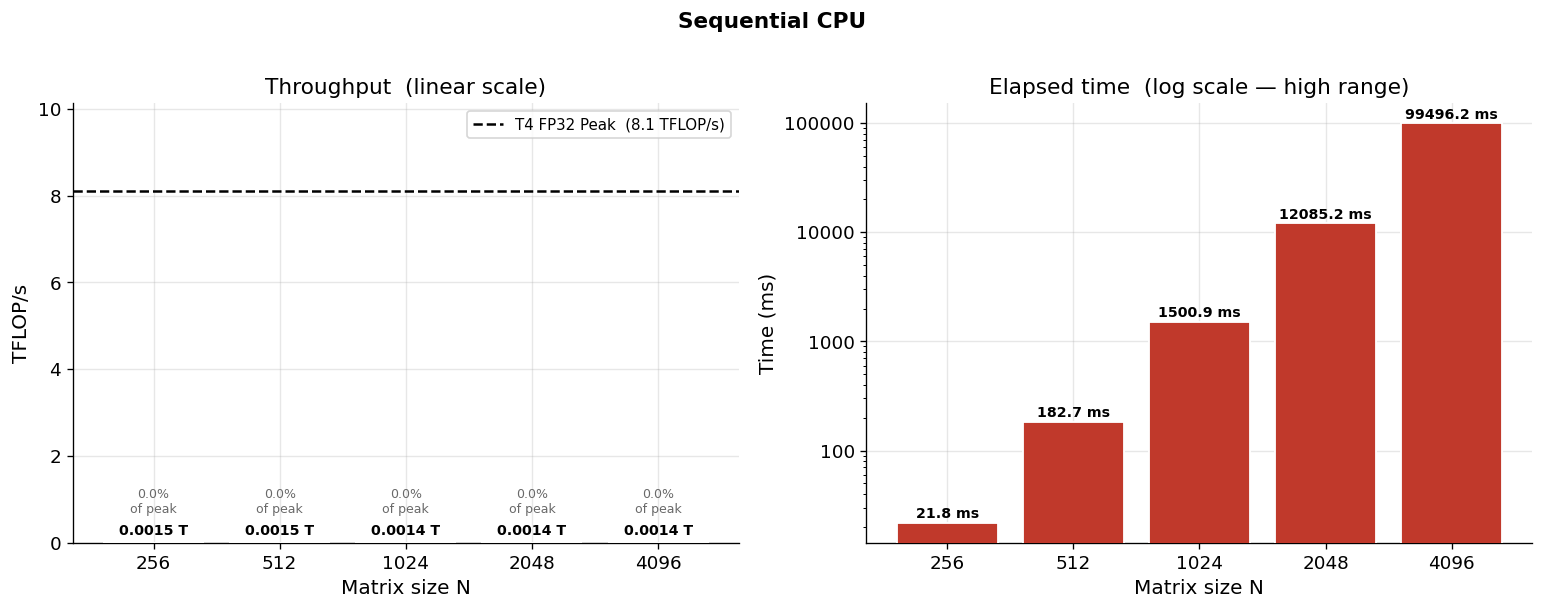

In [22]:
quick_bar(results_seq, title="Sequential CPU")

In [23]:
%%writefile matmul_naive.cu
#include "helpers.h"

static double naive_arith_intensity(int N)
{
    double flops = 2.0 * (double)N * N * N;
    double bytes = (2.0 * (double)N * N * N + (double)N * N) * sizeof(float);
    return flops / bytes;
}

__global__ void gemm_naive(
    const float * __restrict__ A,
    const float * __restrict__ B,
    float * __restrict__ C,
    int N
)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row >= N || col >= N) return;
    float sum = 0.0f;
    for (int k = 0; k < N; k++)
        sum += A[row * N + k] * B[k * N + col];
    C[row * N + col] = sum;
}

static void benchmark_size(int N, const char *ref_dir)
{
    size_t bytes = (size_t)N * N * sizeof(float);

    float *h_A = (float *)malloc(bytes);
    float *h_B = (float *)malloc(bytes);
    float *h_C = (float *)malloc(bytes);
    float *h_ref = (float *)malloc(bytes);

    if (!h_A || !h_B || !h_C || !h_ref) {
        fprintf(stderr, "[ERROR] malloc failed N=%d\n", N);
        free(h_A); free(h_B); free(h_C); free(h_ref);
        return;
    }

    unsigned int seed = RAND_SEED;
    init_matrix(h_A, N, &seed);
    init_matrix(h_B, N, &seed);

    float *d_A, *d_B, *d_C;

    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);

    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    dim3 block(BLOCK_DIM, BLOCK_DIM);
    dim3 grid((N + BLOCK_DIM - 1) / BLOCK_DIM,
              (N + BLOCK_DIM - 1) / BLOCK_DIM);

    gemm_naive<<<grid, block>>>(d_A, d_B, d_C, N);

    cudaDeviceSynchronize();
    cudaGetLastError();

    cudaEvent_t ev_start, ev_stop;

    cudaEventCreate(&ev_start);
    cudaEventCreate(&ev_stop);

    double times[N_RUNS];
    for (int r = 0; r < N_RUNS; r++) {
        cudaMemset(d_C, 0, bytes);
        cudaEventRecord(ev_start);
        gemm_naive<<<grid, block>>>(d_A, d_B, d_C, N);
        cudaEventRecord(ev_stop);
        cudaEventSynchronize(ev_stop);
        
        float elapsed_ms;
        cudaEventElapsedTime(&elapsed_ms, ev_start, ev_stop);
        times[r] = (double)elapsed_ms;
    }

    cudaEventDestroy(ev_start);
    cudaEventDestroy(ev_stop);
    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);

    double time_ms = median(times, N_RUNS);
    double tflops = tflops_s(N, time_ms);
    double csum = checksum(h_C, N);
    double ai = naive_arith_intensity(N);

    int ref_ok = load_reference(ref_dir, N, h_ref);
    double ref_csum = ref_ok ? checksum(h_ref, N) : 0.0;
    double diff = ref_ok ? fabs(ref_csum - csum) : -1.0;
    int correct = ref_ok ? (diff <= 1e-2 * (fabs(ref_csum) + 1e-9)) : -1;

    printf("METRIC|step=naive|variant=|impl=Naive CUDA|N=%d"
           "|time_ms=%.4f|tflops=%.6f|checksum=%.4f"
           "|theo_arith_intensity=%.4f|correct=%d\n",
           N, (double)time_ms, tflops, csum, ai, correct);
    fprintf(stderr,
            "[naive] N=%-5d time=%8.3f ms %.4f TFLOP/s "
            "AI=%.3f F/B chk=%.2e ref=%s\n",
            N, (double)time_ms, tflops, ai, csum,
            correct < 0 ? "no-ref" : (correct ? "OK" : "FAIL"));

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
}

int main(int argc, char *argv[])
{
    const char *ref_dir = "";
    int default_sizes[] = {256, 512, 1024, 2048};
    int *sizes = default_sizes, n_sizes = 4;
    int custom[32], n_custom = 0;
    if (argc >= 2) {
        if (argv[1][0] < '0' || argv[1][0] > '9') {
            ref_dir = argv[1];
            for (int i = 2; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        } else {
            for (int i = 1; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        }
        if (n_custom > 0) { sizes = custom; n_sizes = n_custom; }
    }
    printf("HEADER|step=naive|impl=Naive CUDA|block=%d|runs=%d\n",
           BLOCK_DIM, N_RUNS);
    for (int i = 0; i < n_sizes; i++)
        benchmark_size(sizes[i], ref_dir);
    printf("DONE|step=naive\n");
    return 0;
}

Writing matmul_naive.cu


In [24]:
ok = suite.compile_cuda(
    "matmul_naive.cu helpers.c",
    "matmul_naive",
    extra_flags="-O2 -arch=sm_75",
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:nvcc] nvcc -O2 -arch=sm_75  -o matmul_naive matmul_naive.cu helpers.c
[Compiler:nvcc] OK


In [25]:
results_naive = suite.run("naive", "./matmul_naive", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_naive)

[Runner] ./matmul_naive ./refs/ 256 512 1024 2048 4096
[naive] N=256   time=   0.133 ms 0.2520 TFLOP/s AI=0.250 F/B chk=1.56e+04 ref=OK
[naive] N=512   time=   0.644 ms 0.4167 TFLOP/s AI=0.250 F/B chk=8.17e+04 ref=OK
[naive] N=1024  time=   4.997 ms 0.4297 TFLOP/s AI=0.250 F/B chk=7.98e+04 ref=OK
[naive] N=2048  time=  33.688 ms 0.5100 TFLOP/s AI=0.250 F/B chk=-2.62e+05 ref=OK
[naive] N=4096  time= 229.663 ms 0.5984 TFLOP/s AI=0.250 F/B chk=4.83e+06 ref=OK
[Checker] N=256  checksum match  diff=4.4932e-03  ✓
[Checker] N=512  checksum match  diff=2.7158e-02  ✓
[Checker] N=1024  checksum match  diff=3.1384e-02  ✓
[Checker] N=2048  checksum match  diff=2.3379e-01  ✓
[Checker] N=4096  checksum match  diff=1.2666e+00  ✓

──────────────────────────────────────────────────────────────────────
  naive
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
────────────────────────────────────────────────────────────────────

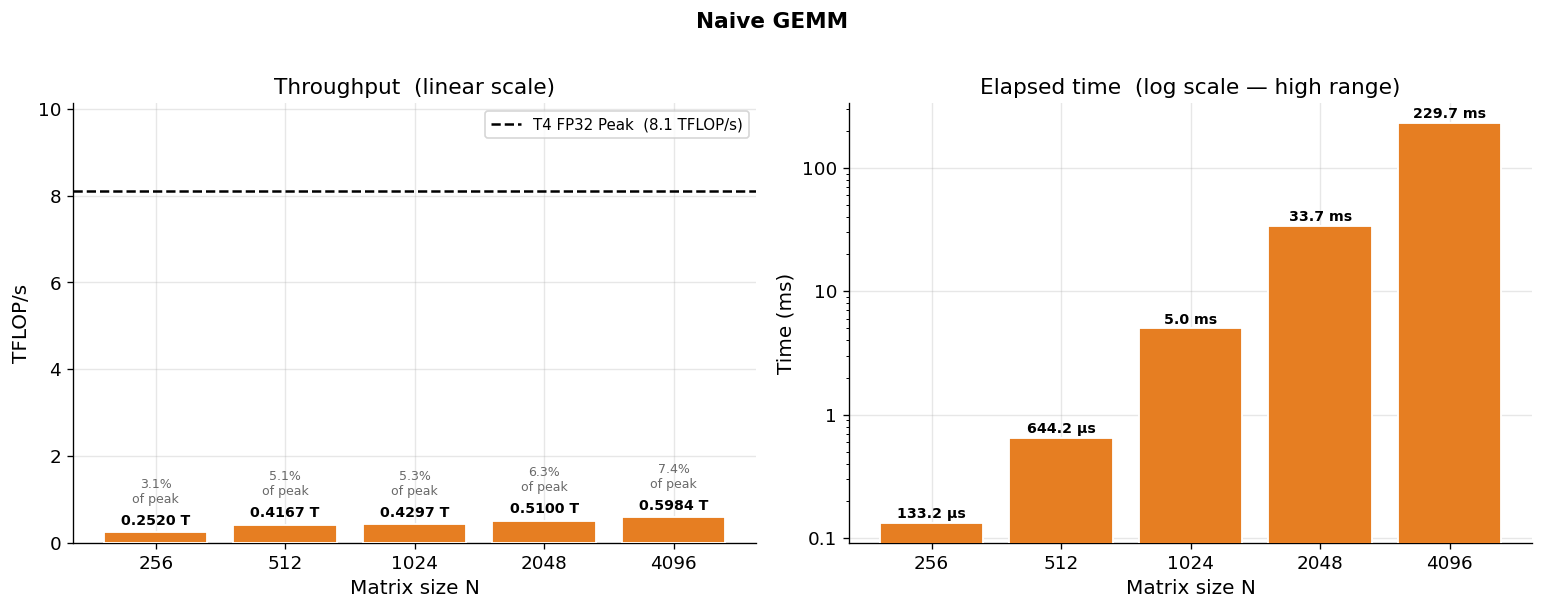

In [26]:
quick_bar(results_naive, title="Naive GEMM")

In [27]:
%%writefile matmul_tiled.cu
#include "helpers.h"

static double tiled_arith_intensity(int N, int tile)
{
    double flops   = 2.0 * (double)N * N * N;
    double bytes_a = (double)N * N * N / tile * sizeof(float);
    double bytes_b = (double)N * N * N / tile * sizeof(float);
    double bytes_c = (double)N * N           * sizeof(float);
    return flops / (bytes_a + bytes_b + bytes_c);
}

__global__ void gemm_tiled(const float * __restrict__ A,
                           const float * __restrict__ B,
                           float       * __restrict__ C,
                           int N)
{
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];

    int ty  = threadIdx.y,  tx  = threadIdx.x;
    int row = blockIdx.y * TILE + ty;
    int col = blockIdx.x * TILE + tx;

    float sum = 0.0f;

    for (int t = 0; t < N / TILE; t++) {
        As[ty][tx] = A[row * N + t * TILE + tx];
        Bs[ty][tx] = B[(t * TILE + ty) * N + col];

        __syncthreads();

        for (int k = 0; k < TILE; k++)
            sum += As[ty][k] * Bs[k][tx];

        __syncthreads();
    }

    if (row < N && col < N)
        C[row * N + col] = sum;
}

static void benchmark_size(int N, const char *ref_dir)
{
    if (N % TILE != 0) {
        fprintf(stderr, "[SKIP] N=%d is not a multiple of TILE=%d\n", N, TILE);
        return;
    }

    size_t bytes = (size_t)N * N * sizeof(float);

    float *h_A   = (float *)malloc(bytes);
    float *h_B   = (float *)malloc(bytes);
    float *h_C   = (float *)malloc(bytes);
    float *h_ref = (float *)malloc(bytes);

    unsigned int seed = RAND_SEED;
    init_matrix(h_A, N, &seed);
    init_matrix(h_B, N, &seed);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    dim3 block(TILE, TILE);
    dim3 grid(N / TILE, N / TILE);

    gemm_tiled<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();
    cudaGetLastError();

    cudaEvent_t ev_start, ev_stop;
    cudaEventCreate(&ev_start);
    cudaEventCreate(&ev_stop);

    double times[N_RUNS];
    for (int r = 0; r < N_RUNS; r++) {
        cudaMemset(d_C, 0, bytes);
        cudaEventRecord(ev_start);
        gemm_tiled<<<grid, block>>>(d_A, d_B, d_C, N);
        cudaEventRecord(ev_stop);
        cudaEventSynchronize(ev_stop);

        float elapsed_ms;
        cudaEventElapsedTime(&elapsed_ms, ev_start, ev_stop);
        times[r] = (double)elapsed_ms;    
    }

    cudaEventDestroy(ev_start);
    cudaEventDestroy(ev_stop);
    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);

    double time_ms = median(times, N_RUNS);
    double tflops = tflops_s(N, time_ms);
    double csum = checksum(h_C, N);
    double ai = tiled_arith_intensity(N, TILE);

    int ref_ok      = load_reference(ref_dir, N, h_ref);
    double ref_csum = ref_ok ? checksum(h_ref, N) : 0.0;
    double diff     = ref_ok ? fabs(ref_csum - csum) : -1.0;
    int correct     = ref_ok ? (diff <= 1e-2 * (fabs(ref_csum) + 1e-9)) : -1;

    printf("METRIC|step=tiled|variant=TILE%d|impl=Tiled GEMM (TILE=%d)|N=%d"
           "|time_ms=%.4f|tflops=%.6f|checksum=%.4f"
           "|theo_arith_intensity=%.4f|correct=%d\n",
           TILE, TILE, N, (double)time_ms, tflops, csum, ai, correct);

    fprintf(stderr,
            "[tiled T%d] N=%-5d  time=%8.3f ms  %.4f TFLOP/s  "
            "AI=%.2f F/B  ref=%s\n",
            TILE, N, (double)time_ms, tflops, ai,
            correct < 0 ? "no-ref" : (correct ? "OK" : "FAIL"));

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
}

int main(int argc, char *argv[])
{
    const char *ref_dir = "";
    int default_sizes[] = {256, 512, 1024, 2048};
    int *sizes = default_sizes, n_sizes = 4;
    int custom[32], n_custom = 0;

    if (argc >= 2) {
        if (argv[1][0] < '0' || argv[1][0] > '9') {
            ref_dir = argv[1];
            for (int i = 2; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        } else {
            for (int i = 1; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        }
        if (n_custom > 0) { sizes = custom; n_sizes = n_custom; }
    }

    printf("HEADER|step=tiled|variant=TILE%d|impl=Tiled GEMM (TILE=%d)|runs=%d\n",
           TILE, TILE, N_RUNS);

    for (int i = 0; i < n_sizes; i++)
        benchmark_size(sizes[i], ref_dir);

    printf("DONE|step=tiled\n");
    return 0;
}

Writing matmul_tiled.cu


In [28]:
ok = suite.compile_cuda(
    "matmul_tiled.cu helpers.c",
    "matmul_tiled16",
    extra_flags="-O2 -arch=sm_75 -DTILE=16",
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:nvcc] nvcc -O2 -arch=sm_75 -DTILE=16  -o matmul_tiled16 matmul_tiled.cu helpers.c
[Compiler:nvcc] OK


In [29]:
results_tiled_16 = suite.run("tiled_TILE16", "./matmul_tiled16", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_tiled_16)

[Runner] ./matmul_tiled16 ./refs/ 256 512 1024 2048 4096
[tiled T16] N=256    time=   0.097 ms  0.3474 TFLOP/s  AI=3.88 F/B  ref=OK
[tiled T16] N=512    time=   0.660 ms  0.4070 TFLOP/s  AI=3.94 F/B  ref=OK
[tiled T16] N=1024   time=   5.145 ms  0.4174 TFLOP/s  AI=3.97 F/B  ref=OK
[tiled T16] N=2048   time=  45.183 ms  0.3802 TFLOP/s  AI=3.98 F/B  ref=OK
[tiled T16] N=4096   time= 201.837 ms  0.6809 TFLOP/s  AI=3.99 F/B  ref=OK
[Checker] N=256  checksum match  diff=4.4932e-03  ✓
[Checker] N=512  checksum match  diff=2.7158e-02  ✓
[Checker] N=1024  checksum match  diff=3.1384e-02  ✓
[Checker] N=2048  checksum match  diff=2.3379e-01  ✓
[Checker] N=4096  checksum match  diff=1.2666e+00  ✓

──────────────────────────────────────────────────────────────────────
  tiled_TILE16
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
──────────────────────────────────────────────────────────────────────
     256          0

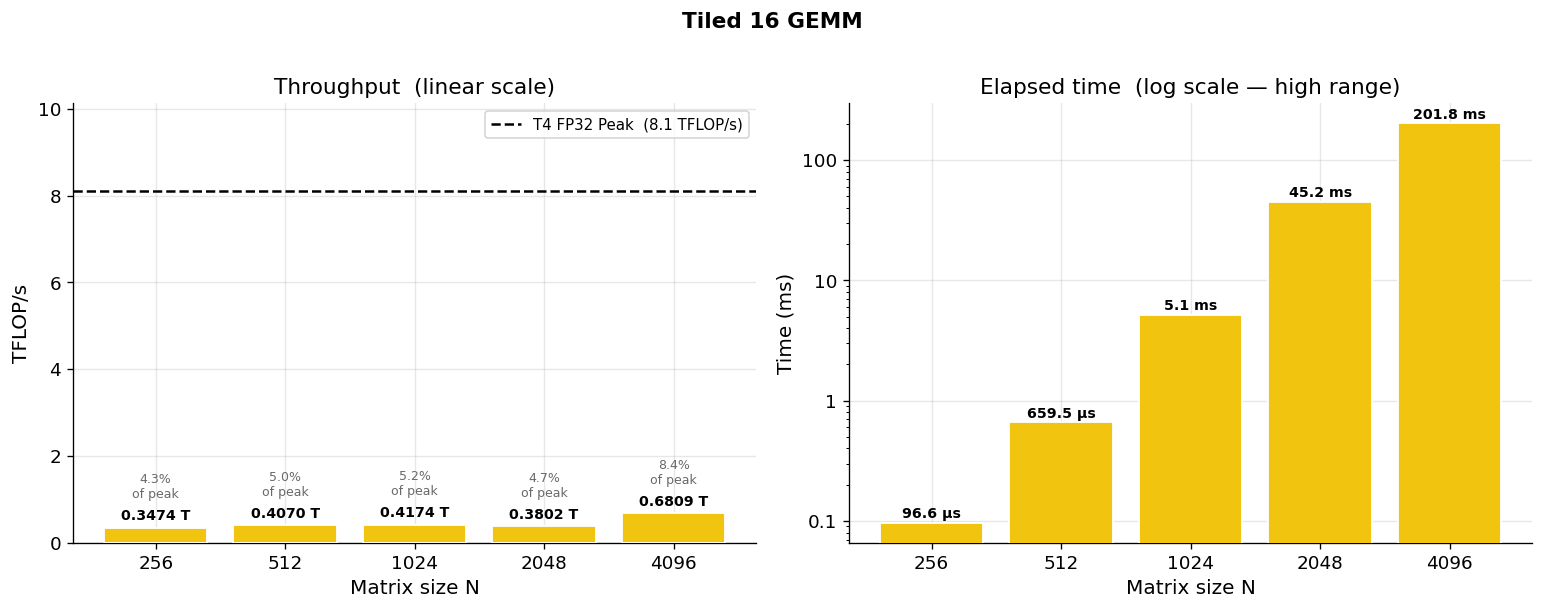

In [30]:
quick_bar(results_tiled_16, title="Tiled 16 GEMM")

In [31]:
ok = suite.compile_cuda(
    "matmul_tiled.cu helpers.c",
    "matmul_tiled32",
    extra_flags="-O2 -arch=sm_75 -DTILE=32",
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:nvcc] nvcc -O2 -arch=sm_75 -DTILE=32  -o matmul_tiled32 matmul_tiled.cu helpers.c
[Compiler:nvcc] OK


In [32]:
results_tiled_32 = suite.run("tiled_TILE32", "./matmul_tiled32", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_tiled_32)

[Runner] ./matmul_tiled32 ./refs/ 256 512 1024 2048 4096
[tiled T32] N=256    time=   0.082 ms  0.4096 TFLOP/s  AI=7.53 F/B  ref=OK
[tiled T32] N=512    time=   0.528 ms  0.5080 TFLOP/s  AI=7.76 F/B  ref=OK
[tiled T32] N=1024   time=   3.984 ms  0.5390 TFLOP/s  AI=7.88 F/B  ref=OK
[tiled T32] N=2048   time=  28.889 ms  0.5947 TFLOP/s  AI=7.94 F/B  ref=OK
[tiled T32] N=4096   time= 152.938 ms  0.8987 TFLOP/s  AI=7.97 F/B  ref=OK
[Checker] N=256  checksum match  diff=4.4932e-03  ✓
[Checker] N=512  checksum match  diff=2.7158e-02  ✓
[Checker] N=1024  checksum match  diff=3.1384e-02  ✓
[Checker] N=2048  checksum match  diff=2.3379e-01  ✓
[Checker] N=4096  checksum match  diff=1.2666e+00  ✓

──────────────────────────────────────────────────────────────────────
  tiled_TILE32
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
──────────────────────────────────────────────────────────────────────
     256          0

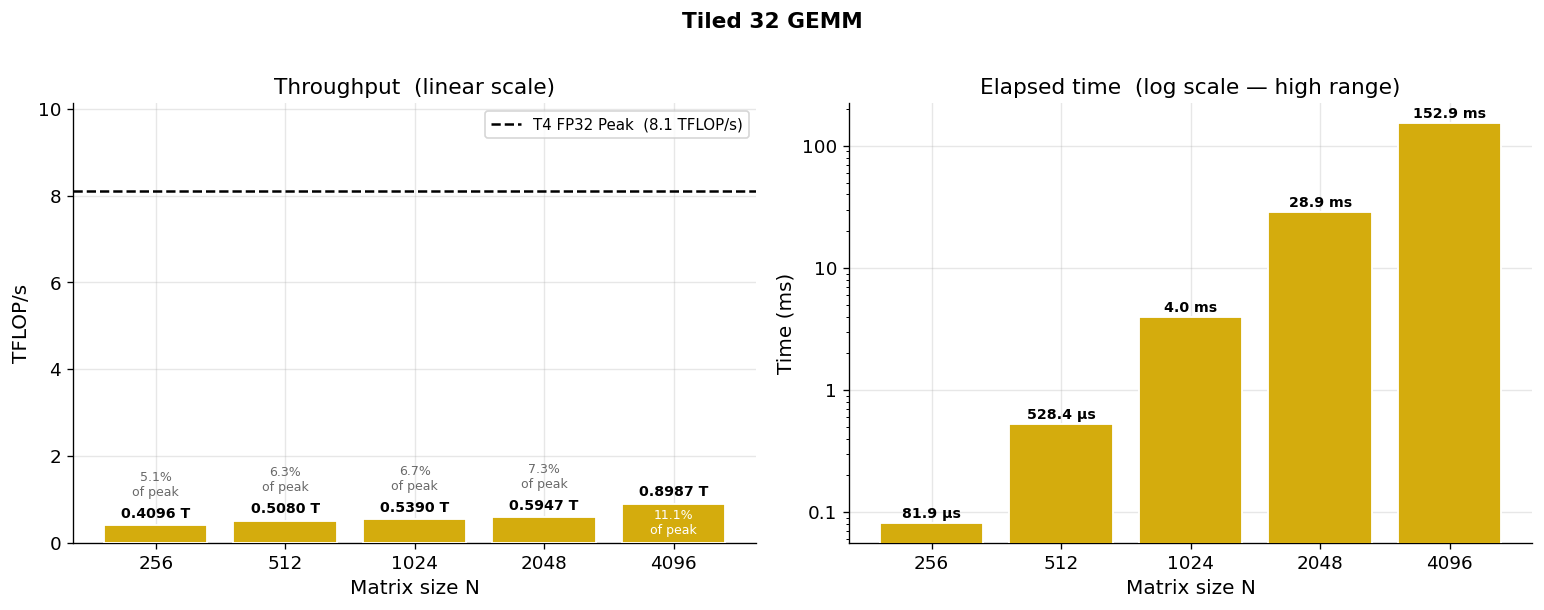

In [33]:
quick_bar(results_tiled_32, title="Tiled 32 GEMM")

In [34]:
%%writefile matmul_padded.cu
#include "helpers.h"

static double tiled_arith_intensity(int N, int tile)
{
    double flops   = 2.0 * (double)N * N * N;
    double bytes_a = (double)N * N * N / tile * sizeof(float);
    double bytes_b = (double)N * N * N / tile * sizeof(float);
    double bytes_c = (double)N * N           * sizeof(float);
    return flops / (bytes_a + bytes_b + bytes_c);
}

__global__ void gemm_tiled(const float * __restrict__ A,
                           const float * __restrict__ B,
                           float       * __restrict__ C,
                           int N)
{
    __shared__ float As[TILE][TILE+1];
    __shared__ float Bs[TILE][TILE+1];

    int ty  = threadIdx.y,  tx  = threadIdx.x;
    int row = blockIdx.y * TILE + ty;
    int col = blockIdx.x * TILE + tx;

    float sum = 0.0f;

    for (int t = 0; t < N / TILE; t++) {
        As[ty][tx] = A[row * N + t * TILE + tx];
        Bs[ty][tx] = B[(t * TILE + ty) * N + col];

        __syncthreads();

        for (int k = 0; k < TILE; k++)
            sum += As[ty][k] * Bs[k][tx];

        __syncthreads();
    }

    if (row < N && col < N)
        C[row * N + col] = sum;
}

static void benchmark_size(int N, const char *ref_dir)
{
    if (N % TILE != 0) {
        fprintf(stderr, "[SKIP] N=%d is not a multiple of TILE=%d\n", N, TILE);
        return;
    }

    size_t bytes = (size_t)N * N * sizeof(float);

    float *h_A   = (float *)malloc(bytes);
    float *h_B   = (float *)malloc(bytes);
    float *h_C   = (float *)malloc(bytes);
    float *h_ref = (float *)malloc(bytes);

    unsigned int seed = RAND_SEED;
    init_matrix(h_A, N, &seed);
    init_matrix(h_B, N, &seed);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    dim3 block(TILE, TILE);
    dim3 grid(N / TILE, N / TILE);

    gemm_tiled<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();
    cudaGetLastError();

    cudaEvent_t ev_start, ev_stop;
    cudaEventCreate(&ev_start);
    cudaEventCreate(&ev_stop);

    double times[N_RUNS];
    for (int r = 0; r < N_RUNS; r++) {
        cudaMemset(d_C, 0, bytes);
        cudaEventRecord(ev_start);
        gemm_tiled<<<grid, block>>>(d_A, d_B, d_C, N);
        cudaEventRecord(ev_stop);
        cudaEventSynchronize(ev_stop);

        float elapsed_ms;
        cudaEventElapsedTime(&elapsed_ms, ev_start, ev_stop);
        times[r] = (double)elapsed_ms;    
    }

    cudaEventDestroy(ev_start);
    cudaEventDestroy(ev_stop);
    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);

    double time_ms = median(times, N_RUNS);
    double tflops = tflops_s(N, time_ms);
    double csum = checksum(h_C, N);
    double ai = tiled_arith_intensity(N, TILE);

    int ref_ok      = load_reference(ref_dir, N, h_ref);
    double ref_csum = ref_ok ? checksum(h_ref, N) : 0.0;
    double diff     = ref_ok ? fabs(ref_csum - csum) : -1.0;
    int correct     = ref_ok ? (diff <= 1e-2 * (fabs(ref_csum) + 1e-9)) : -1;

    printf("METRIC|step=tiled|variant=TILE%d|impl=Tiled GEMM (TILE=%d)|N=%d"
           "|time_ms=%.4f|tflops=%.6f|checksum=%.4f"
           "|theo_arith_intensity=%.4f|correct=%d\n",
           TILE, TILE, N, (double)time_ms, tflops, csum, ai, correct);

    fprintf(stderr,
            "[tiled T%d] N=%-5d  time=%8.3f ms  %.4f TFLOP/s  "
            "AI=%.2f F/B  ref=%s\n",
            TILE, N, (double)time_ms, tflops, ai,
            correct < 0 ? "no-ref" : (correct ? "OK" : "FAIL"));

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
}

int main(int argc, char *argv[])
{
    const char *ref_dir = "";
    int default_sizes[] = {256, 512, 1024, 2048};
    int *sizes = default_sizes, n_sizes = 4;
    int custom[32], n_custom = 0;

    if (argc >= 2) {
        if (argv[1][0] < '0' || argv[1][0] > '9') {
            ref_dir = argv[1];
            for (int i = 2; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        } else {
            for (int i = 1; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        }
        if (n_custom > 0) { sizes = custom; n_sizes = n_custom; }
    }

    printf("HEADER|step=tiled|variant=TILE%d|impl=Tiled GEMM (TILE=%d)|runs=%d\n",
           TILE, TILE, N_RUNS);

    for (int i = 0; i < n_sizes; i++)
        benchmark_size(sizes[i], ref_dir);

    printf("DONE|step=tiled\n");
    return 0;
}

Writing matmul_padded.cu


In [35]:
ok = suite.compile_cuda(
    "matmul_padded.cu helpers.c",
    "matmul_padded16",
    extra_flags="-O2 -arch=sm_75 -DTILE=16",
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:nvcc] nvcc -O2 -arch=sm_75 -DTILE=16  -o matmul_padded16 matmul_padded.cu helpers.c
[Compiler:nvcc] OK


In [36]:
results_padded_16 = suite.run("padded_TILE16", "./matmul_padded16", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_padded_16)

[Runner] ./matmul_padded16 ./refs/ 256 512 1024 2048 4096
[tiled T16] N=256    time=   0.140 ms  0.2392 TFLOP/s  AI=3.88 F/B  ref=OK
[tiled T16] N=512    time=   0.980 ms  0.2739 TFLOP/s  AI=3.94 F/B  ref=OK
[tiled T16] N=1024   time=   7.651 ms  0.2807 TFLOP/s  AI=3.97 F/B  ref=OK
[tiled T16] N=2048   time=  36.411 ms  0.4718 TFLOP/s  AI=3.98 F/B  ref=OK
[tiled T16] N=4096   time= 252.256 ms  0.5448 TFLOP/s  AI=3.99 F/B  ref=OK
[Checker] N=256  checksum match  diff=4.4932e-03  ✓
[Checker] N=512  checksum match  diff=2.7158e-02  ✓
[Checker] N=1024  checksum match  diff=3.1384e-02  ✓
[Checker] N=2048  checksum match  diff=2.3379e-01  ✓
[Checker] N=4096  checksum match  diff=1.2666e+00  ✓

──────────────────────────────────────────────────────────────────────
  padded_TILE16
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
──────────────────────────────────────────────────────────────────────
     256         

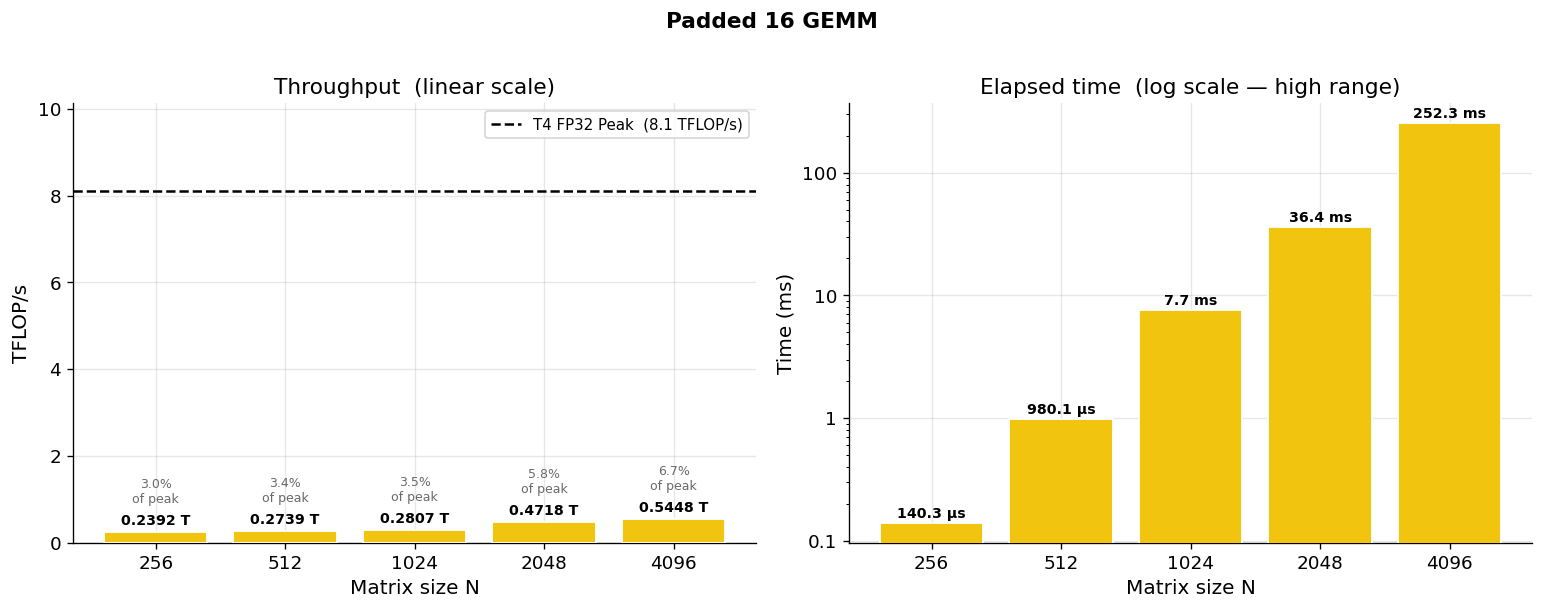

In [37]:
quick_bar(results_padded_16, title="Padded 16 GEMM")

In [38]:
ok = suite.compile_cuda(
    "matmul_padded.cu helpers.c",
    "matmul_padded32",
    extra_flags="-O2 -arch=sm_75 -DTILE=32",
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:nvcc] nvcc -O2 -arch=sm_75 -DTILE=32  -o matmul_padded32 matmul_padded.cu helpers.c
[Compiler:nvcc] OK


In [39]:
results_padded_32 = suite.run("padded_TILE32", "./matmul_padded32", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_padded_32)

[Runner] ./matmul_padded32 ./refs/ 256 512 1024 2048 4096
[tiled T32] N=256    time=   0.135 ms  0.2479 TFLOP/s  AI=7.53 F/B  ref=OK
[tiled T32] N=512    time=   0.905 ms  0.2965 TFLOP/s  AI=7.76 F/B  ref=OK
[tiled T32] N=1024   time=   6.834 ms  0.3142 TFLOP/s  AI=7.88 F/B  ref=OK
[tiled T32] N=2048   time=  30.670 ms  0.5602 TFLOP/s  AI=7.94 F/B  ref=OK
[tiled T32] N=4096   time= 192.903 ms  0.7125 TFLOP/s  AI=7.97 F/B  ref=OK
[Checker] N=256  checksum match  diff=4.4932e-03  ✓
[Checker] N=512  checksum match  diff=2.7158e-02  ✓
[Checker] N=1024  checksum match  diff=3.1384e-02  ✓
[Checker] N=2048  checksum match  diff=2.3379e-01  ✓
[Checker] N=4096  checksum match  diff=1.2666e+00  ✓

──────────────────────────────────────────────────────────────────────
  padded_TILE32
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
──────────────────────────────────────────────────────────────────────
     256         

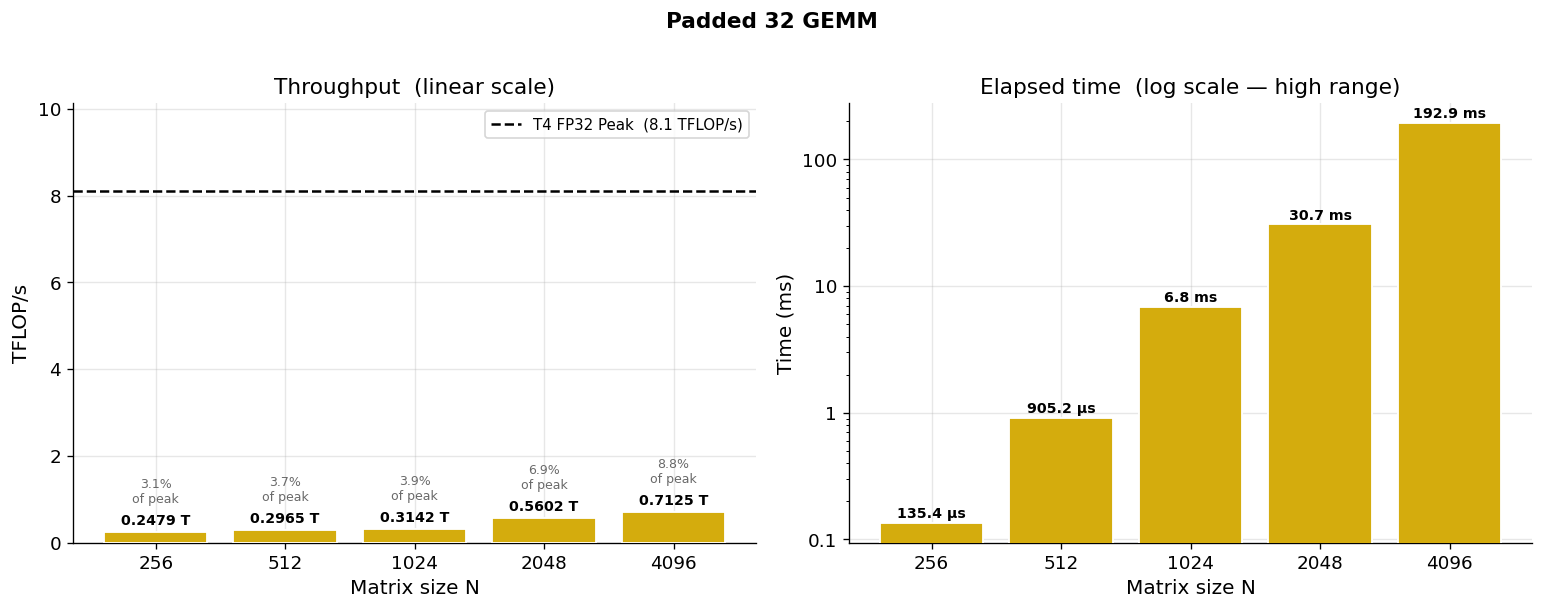

In [40]:
quick_bar(results_padded_32, title="Padded 32 GEMM")

In [41]:
%%writefile matmul_regtile.cu
#include "helpers.h"

static double tiled_arith_intensity(int N, int tile)
{
    double flops   = 2.0 * (double)N * N * N;
    double bytes_a = (double)N * N * N / tile * sizeof(float);
    double bytes_b = (double)N * N * N / tile * sizeof(float);
    double bytes_c = (double)N * N           * sizeof(float);
    return flops / (bytes_a + bytes_b + bytes_c);
}

__global__ void gemm_regtile(const float * __restrict__ A,
                             const float * __restrict__ B,
                             float       * __restrict__ C,
                             int N)
{
    __shared__ float As[TILE][TILE + 1];
    __shared__ float Bs[TILE][TILE + 1];

    int ty  = threadIdx.y,  tx  = threadIdx.x;

    int row = blockIdx.y * TILE + ty * TW;
    int col = blockIdx.x * TILE + tx * TW;

    float regC[TW][TW] = {{0.0f}};

    for (int t = 0; t < N / TILE; t++) {

        for (int i = 0; i < TW; i++) {
            for (int j = 0; j < TW; j++) {
                As[ty * TW + i][tx * TW + j] = A[(row + i) * N + t * TILE + tx * TW + j];
                Bs[ty * TW + i][tx * TW + j] = B[(t * TILE + ty * TW + i) * N + col + j];
            }
        }

        __syncthreads();

        for (int k = 0; k < TILE; k++) {
            float regA[TW], regB[TW];

            for (int i = 0; i < TW; i++)
                regA[i] = As[ty * TW + i][k];

            for (int j = 0; j < TW; j++)
                regB[j] = Bs[k][tx * TW + j];

            for (int i = 0; i < TW; i++)
                for (int j = 0; j < TW; j++)
                    regC[i][j] += regA[i] * regB[j];
        }

        __syncthreads(); 
    }

    for (int i = 0; i < TW; i++)
        for (int j = 0; j < TW; j++)
            C[(row + i) * N + (col + j)] = regC[i][j];
}

static void benchmark_size(int N, const char *ref_dir)
{
    if (N % TILE != 0) {
        fprintf(stderr, "[SKIP] N=%d not multiple of TILE=%d\n", N, TILE);
        return;
    }

    size_t bytes = (size_t)N * N * sizeof(float);

    float *h_A   = (float *)malloc(bytes);
    float *h_B   = (float *)malloc(bytes);
    float *h_C   = (float *)malloc(bytes);
    float *h_ref = (float *)malloc(bytes);

    unsigned int seed = RAND_SEED;
    init_matrix(h_A, N, &seed);
    init_matrix(h_B, N, &seed);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    dim3 block(TILE / TW, TILE / TW);
    dim3 grid(N / TILE, N / TILE);

    gemm_regtile<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();
    cudaGetLastError();

    cudaEvent_t ev_start, ev_stop;
    cudaEventCreate(&ev_start);
    cudaEventCreate(&ev_stop);

    double times[N_RUNS];
    for (int r = 0; r < N_RUNS; r++) {
        cudaMemset(d_C, 0, bytes);
        cudaEventRecord(ev_start);
        gemm_regtile<<<grid, block>>>(d_A, d_B, d_C, N);
        cudaEventRecord(ev_stop);
        cudaEventSynchronize(ev_stop);

        float elapsed_ms;
        cudaEventElapsedTime(&elapsed_ms, ev_start, ev_stop);
        times[r] = (double)elapsed_ms;    
    }

    cudaEventDestroy(ev_start);
    cudaEventDestroy(ev_stop);
    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);

    double time_ms = median(times, N_RUNS);
    double tflops = tflops_s(N, time_ms);
    double csum = checksum(h_C, N);
    double ai = tiled_arith_intensity(N, TILE);

    int ref_ok      = load_reference(ref_dir, N, h_ref);
    double ref_csum = ref_ok ? checksum(h_ref, N) : 0.0;
    double diff     = ref_ok ? fabs(ref_csum - csum) : -1.0;
    int correct     = ref_ok ? (diff <= 1e-2 * (fabs(ref_csum) + 1e-9)) : -1;

    printf("METRIC|step=regtile|variant=|impl=Register Tiling (TILE=%d,TW=%d)|N=%d"
           "|time_ms=%.4f|tflops=%.6f|checksum=%.4f"
           "|theo_arith_intensity=%.4f|correct=%d\n",
           TILE, TW, N, (double)time_ms, tflops, csum, ai, correct);

    fprintf(stderr,
            "[regtile T%d TW%d] N=%-5d  time=%8.3f ms  %.4f TFLOP/s  "
            "AI=%.2f F/B  ref=%s\n",
            TILE, TW, N, (double)time_ms, tflops, ai,
            correct < 0 ? "no-ref" : (correct ? "OK" : "FAIL"));

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
}

int main(int argc, char *argv[])
{
    const char *ref_dir = "";
    int default_sizes[] = {256, 512, 1024, 2048};
    int *sizes = default_sizes, n_sizes = 4;
    int custom[32], n_custom = 0;

    if (argc >= 2) {
        if (argv[1][0] < '0' || argv[1][0] > '9') {
            ref_dir = argv[1];
            for (int i = 2; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        } else {
            for (int i = 1; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        }
        if (n_custom > 0) { sizes = custom; n_sizes = n_custom; }
    }

    printf("HEADER|step=regtile|variant=|impl=Register Tiling (TILE=%d,TW=%d)|runs=%d\n",
           TILE, TW, N_RUNS);

    for (int i = 0; i < n_sizes; i++)
        benchmark_size(sizes[i], ref_dir);

    printf("DONE|step=regtile\n");
    return 0;
}

Writing matmul_regtile.cu


In [42]:
ok = suite.compile_cuda(
    "matmul_regtile.cu helpers.c",
    "matmul_regtile",
    extra_flags="-O2 -arch=sm_75 -DTILE=64 -DTW=4",
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:nvcc] nvcc -O2 -arch=sm_75 -DTILE=64 -DTW=4  -o matmul_regtile matmul_regtile.cu helpers.c
[Compiler:nvcc] OK


In [43]:
results_regtile = suite.run("regtile", "./matmul_regtile", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_regtile)

[Runner] ./matmul_regtile ./refs/ 256 512 1024 2048 4096
[regtile T64 TW4] N=256    time=   0.061 ms  0.5487 TFLOP/s  AI=14.22 F/B  ref=OK
[regtile T64 TW4] N=512    time=   0.355 ms  0.7567 TFLOP/s  AI=15.06 F/B  ref=OK
[regtile T64 TW4] N=1024   time=   2.468 ms  0.8700 TFLOP/s  AI=15.52 F/B  ref=OK
[regtile T64 TW4] N=2048   time=  17.699 ms  0.9707 TFLOP/s  AI=15.75 F/B  ref=OK
[regtile T64 TW4] N=4096   time=  65.130 ms  2.1102 TFLOP/s  AI=15.88 F/B  ref=OK
[Checker] N=256  checksum match  diff=4.4932e-03  ✓
[Checker] N=512  checksum match  diff=2.7158e-02  ✓
[Checker] N=1024  checksum match  diff=3.1384e-02  ✓
[Checker] N=2048  checksum match  diff=2.3379e-01  ✓
[Checker] N=4096  checksum match  diff=1.2666e+00  ✓

──────────────────────────────────────────────────────────────────────
  regtile
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
────────────────────────────────────────────────────────────

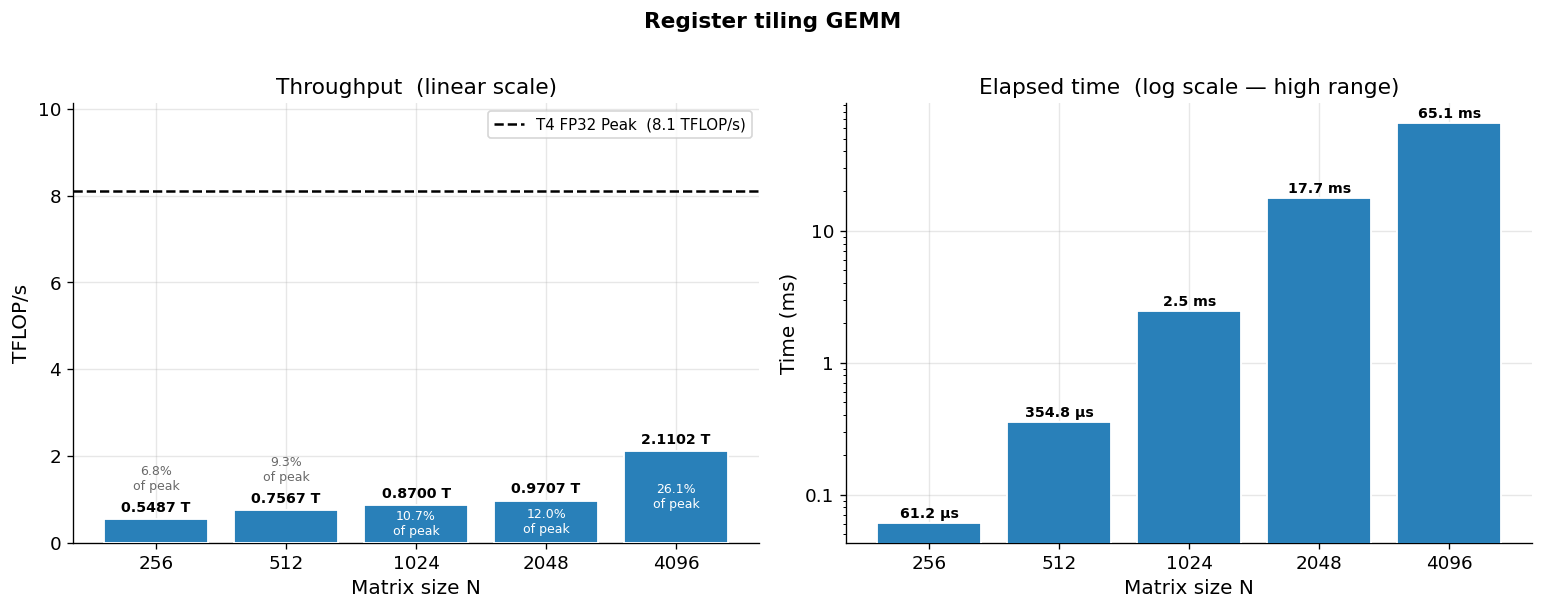

In [44]:
quick_bar(results_regtile, title="Register tiling GEMM")

In [45]:
%%writefile matmul_vec_ldg.cu
#include "helpers.h"

static double tiled_arith_intensity(int N, int tile)
{
    double flops   = 2.0 * (double)N * N * N;
    double bytes_a = (double)N * N * N / tile * sizeof(float);
    double bytes_b = (double)N * N * N / tile * sizeof(float);
    double bytes_c = (double)N * N           * sizeof(float);
    return flops / (bytes_a + bytes_b + bytes_c);
}


__global__ void gemm_vec_ldg(const float * __restrict__ A,
                             const float * __restrict__ B,
                             float       * __restrict__ C,
                             int N)
{
    __shared__ float As[TILE][TILE + 1];
    __shared__ float Bs[TILE][TILE + 1];

    int ty  = threadIdx.y,  tx  = threadIdx.x;
    int row = blockIdx.y * TILE + ty * TW;
    int col = blockIdx.x * TILE + tx * TW;

    float regC[TW][TW] = {{0.0f}};

    for (int t = 0; t < N / TILE; t++) {

        for (int i = 0; i < TW; i++) {

            float4 a4 = __ldg((const float4 *)
                              &A[(row + i) * N + t * TILE + tx * 4]);
            As[ty * TW + i][tx * 4 + 0] = a4.x;
            As[ty * TW + i][tx * 4 + 1] = a4.y;
            As[ty * TW + i][tx * 4 + 2] = a4.z;
            As[ty * TW + i][tx * 4 + 3] = a4.w;

            float4 b4 = __ldg((const float4 *)
                              &B[(t * TILE + ty * TW + i) * N + col]);
            Bs[ty * TW + i][tx * 4 + 0] = b4.x;
            Bs[ty * TW + i][tx * 4 + 1] = b4.y;
            Bs[ty * TW + i][tx * 4 + 2] = b4.z;
            Bs[ty * TW + i][tx * 4 + 3] = b4.w;
        }

        __syncthreads();

        for (int k = 0; k < TILE; k++) {
            float regA[TW], regB[TW];

            for (int i = 0; i < TW; i++)
                regA[i] = As[ty * TW + i][k];

            for (int j = 0; j < TW; j++)
                regB[j] = Bs[k][tx * TW + j];

            for (int i = 0; i < TW; i++)
                for (int j = 0; j < TW; j++)
                    regC[i][j] += regA[i] * regB[j];
        }

        __syncthreads();
    }

    for (int i = 0; i < TW; i++)
        for (int j = 0; j < TW; j++)
            C[(row + i) * N + (col + j)] = regC[i][j];
}


static void benchmark_size(int N, const char *ref_dir)
{
    if (N % TILE != 0 || N % 4 != 0) {
        fprintf(stderr, "[SKIP] N=%d must be multiple of TILE=%d and 4\n", N, TILE);
        return;
    }

    size_t bytes = (size_t)N * N * sizeof(float);

    float *h_A   = (float *)malloc(bytes);
    float *h_B   = (float *)malloc(bytes);
    float *h_C   = (float *)malloc(bytes);
    float *h_ref = (float *)malloc(bytes);

    unsigned int seed = RAND_SEED;
    init_matrix(h_A, N, &seed);
    init_matrix(h_B, N, &seed);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    dim3 block(TILE / TW, TILE / TW);
    dim3 grid(N / TILE, N / TILE);

    gemm_vec_ldg<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();
    cudaGetLastError();

    cudaEvent_t ev_start, ev_stop;
    cudaEventCreate(&ev_start);
    cudaEventCreate(&ev_stop);

    double times[N_RUNS];
    for (int r = 0; r < N_RUNS; r++) {
        cudaMemset(d_C, 0, bytes);
        cudaEventRecord(ev_start);
        gemm_vec_ldg<<<grid, block>>>(d_A, d_B, d_C, N);
        cudaEventRecord(ev_stop);
        cudaEventSynchronize(ev_stop);

        float elapsed_ms;
        cudaEventElapsedTime(&elapsed_ms, ev_start, ev_stop);
        times[r] = (double)elapsed_ms;    
    }

    cudaEventDestroy(ev_start);
    cudaEventDestroy(ev_stop);
    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);

    double time_ms = median(times, N_RUNS);
    double tflops = tflops_s(N, time_ms);
    double csum = checksum(h_C, N);
    double ai = tiled_arith_intensity(N, TILE);

    int ref_ok      = load_reference(ref_dir, N, h_ref);
    double ref_csum = ref_ok ? checksum(h_ref, N) : 0.0;
    double diff     = ref_ok ? fabs(ref_csum - csum) : -1.0;
    int correct     = ref_ok ? (diff <= 1e-2 * (fabs(ref_csum) + 1e-9)) : -1;

    printf("METRIC|step=vec_ldg|variant=|impl=Vec Loads + __ldg() (TILE=%d,TW=%d)|N=%d"
           "|time_ms=%.4f|tflops=%.6f|checksum=%.4f"
           "|theo_arith_intensity=%.4f|correct=%d\n",
           TILE, TW, N, (double)time_ms, tflops, csum, ai, correct);

    fprintf(stderr,
            "[vec_ldg T%d TW%d] N=%-5d  time=%8.3f ms  %.4f TFLOP/s  "
            "AI=%.2f F/B  ref=%s\n",
            TILE, TW, N, (double)time_ms, tflops, ai,
            correct < 0 ? "no-ref" : (correct ? "OK" : "FAIL"));

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
}

int main(int argc, char *argv[])
{
    const char *ref_dir = "";
    int default_sizes[] = {256, 512, 1024, 2048};
    int *sizes = default_sizes, n_sizes = 4;
    int custom[32], n_custom = 0;

    if (argc >= 2) {
        if (argv[1][0] < '0' || argv[1][0] > '9') {
            ref_dir = argv[1];
            for (int i = 2; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        } else {
            for (int i = 1; i < argc && n_custom < 32; i++)
                custom[n_custom++] = atoi(argv[i]);
        }
        if (n_custom > 0) { sizes = custom; n_sizes = n_custom; }
    }

    printf("HEADER|step=vec_ldg|variant=|impl=Vec Loads + __ldg() (TILE=%d,TW=%d)|runs=%d\n",
           TILE, TW, N_RUNS);

    for (int i = 0; i < n_sizes; i++)
        benchmark_size(sizes[i], ref_dir);

    printf("DONE|step=vec_ldg\n");
    return 0;
}



Writing matmul_vec_ldg.cu


In [46]:
ok = suite.compile_cuda(
    "matmul_vec_ldg.cu helpers.c",
    "matmul_vec_ldg",
    extra_flags="-O2 -arch=sm_75 -DTILE=64 -DTW=4",
)
assert ok, "Compilation failed — fix errors before proceeding."

[Compiler:nvcc] nvcc -O2 -arch=sm_75 -DTILE=64 -DTW=4  -o matmul_vec_ldg matmul_vec_ldg.cu helpers.c
[Compiler:nvcc] OK


In [47]:
results_vec_ldg = suite.run("vec_ldg", "./matmul_vec_ldg", sizes=[256, 512, 1024, 2048, 4096], verify=True)
print_metrics_table(results_vec_ldg)

[Runner] ./matmul_vec_ldg ./refs/ 256 512 1024 2048 4096
[vec_ldg T64 TW4] N=256    time=   0.056 ms  0.5944 TFLOP/s  AI=14.22 F/B  ref=OK
[vec_ldg T64 TW4] N=512    time=   0.307 ms  0.8746 TFLOP/s  AI=15.06 F/B  ref=OK
[vec_ldg T64 TW4] N=1024   time=   2.081 ms  1.0320 TFLOP/s  AI=15.52 F/B  ref=OK
[vec_ldg T64 TW4] N=2048   time=  13.912 ms  1.2349 TFLOP/s  AI=15.75 F/B  ref=OK
[vec_ldg T64 TW4] N=4096   time=  58.355 ms  2.3552 TFLOP/s  AI=15.88 F/B  ref=OK
[Checker] N=256  checksum match  diff=4.4932e-03  ✓
[Checker] N=512  checksum match  diff=2.7158e-02  ✓
[Checker] N=1024  checksum match  diff=3.1384e-02  ✓
[Checker] N=2048  checksum match  diff=2.3379e-01  ✓
[Checker] N=4096  checksum match  diff=1.2666e+00  ✓

──────────────────────────────────────────────────────────────────────
  vec_ldg
──────────────────────────────────────────────────────────────────────
       N     time (ms)     TFLOP/s    AI (F/B)   correct
────────────────────────────────────────────────────────────

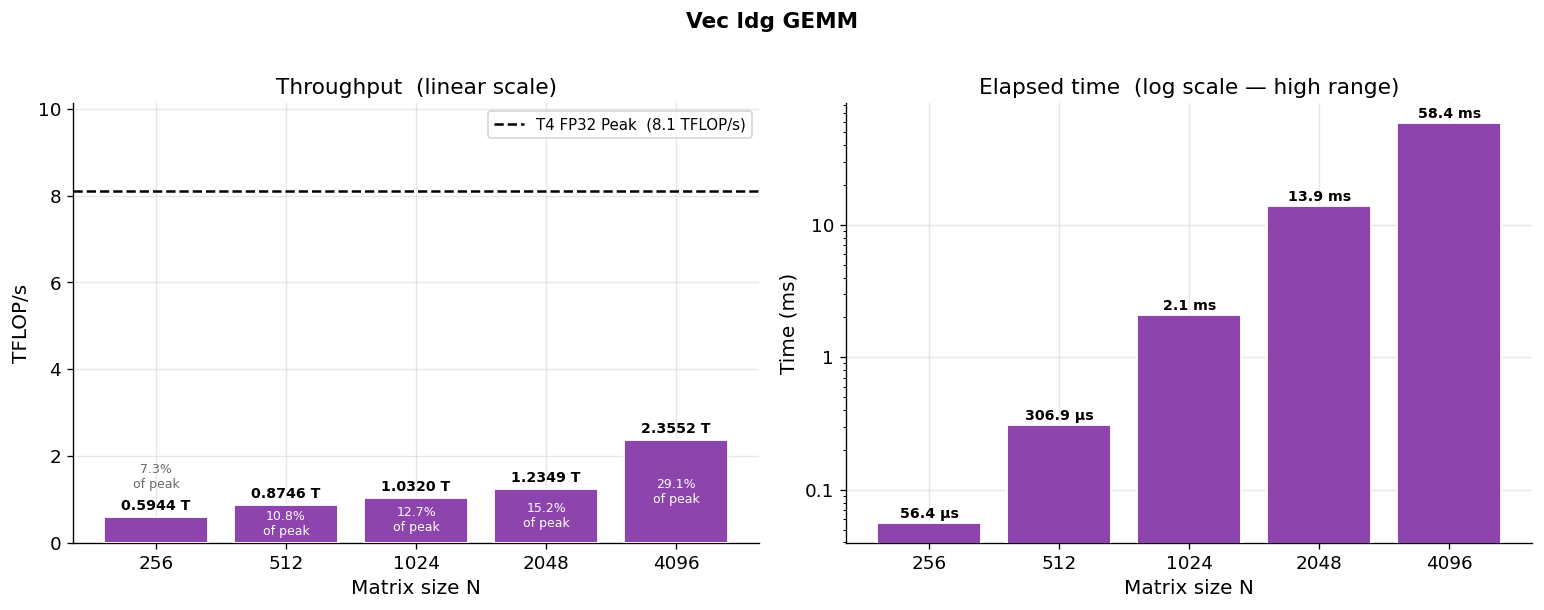

In [48]:
quick_bar(results_vec_ldg, title="Vec ldg GEMM")

[Plot] Generating all figures …
[Plot] Saved → figures/bar_tflops_N1024.png


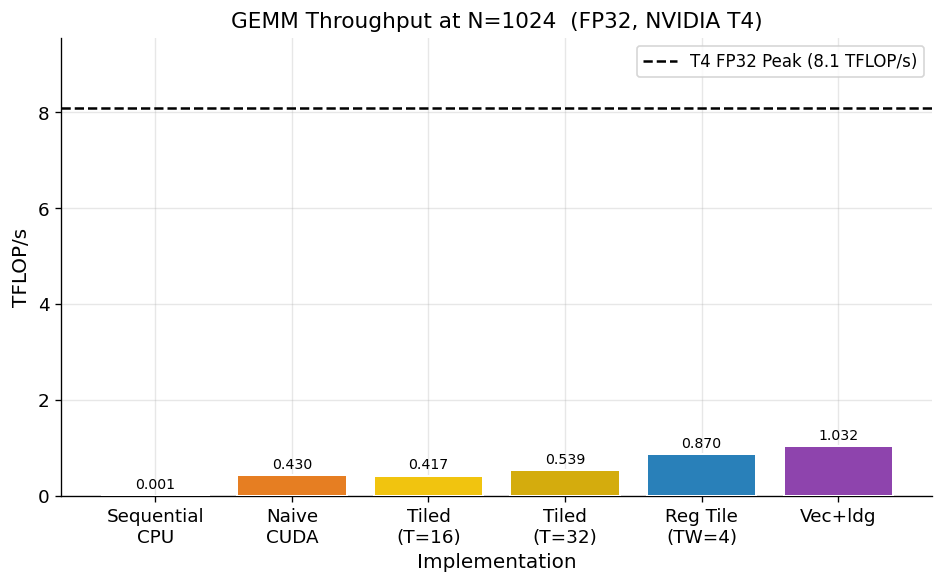

[Plot] Saved → figures/line_tflops_vs_N.png


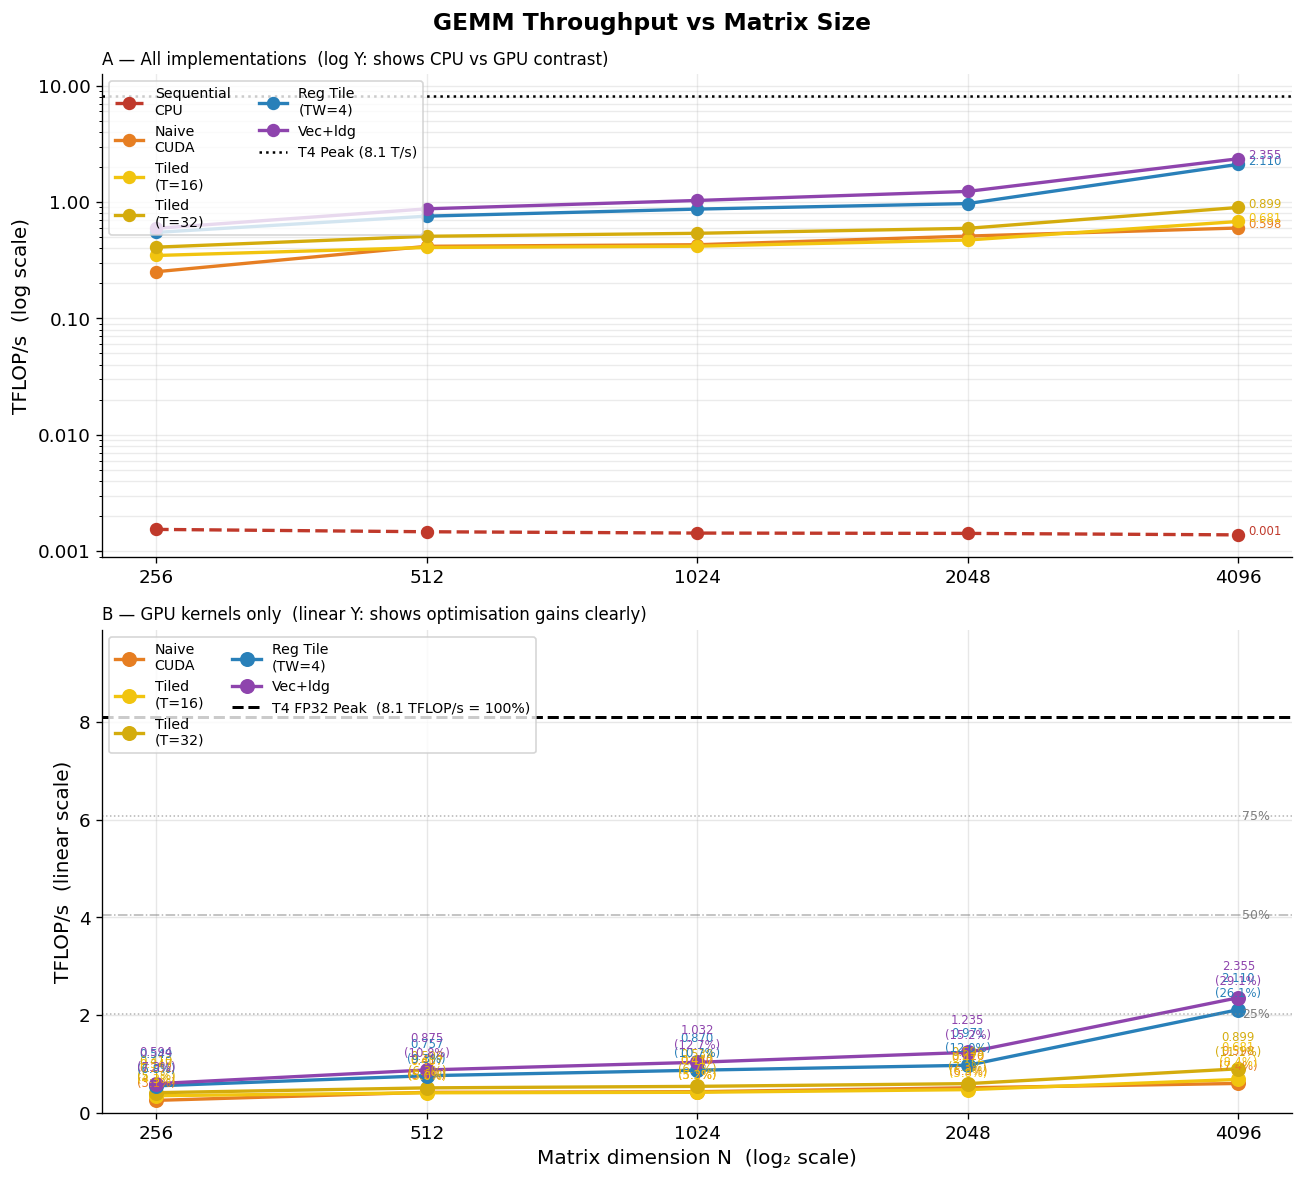

[Plot] Saved → figures/line_time_vs_N.png


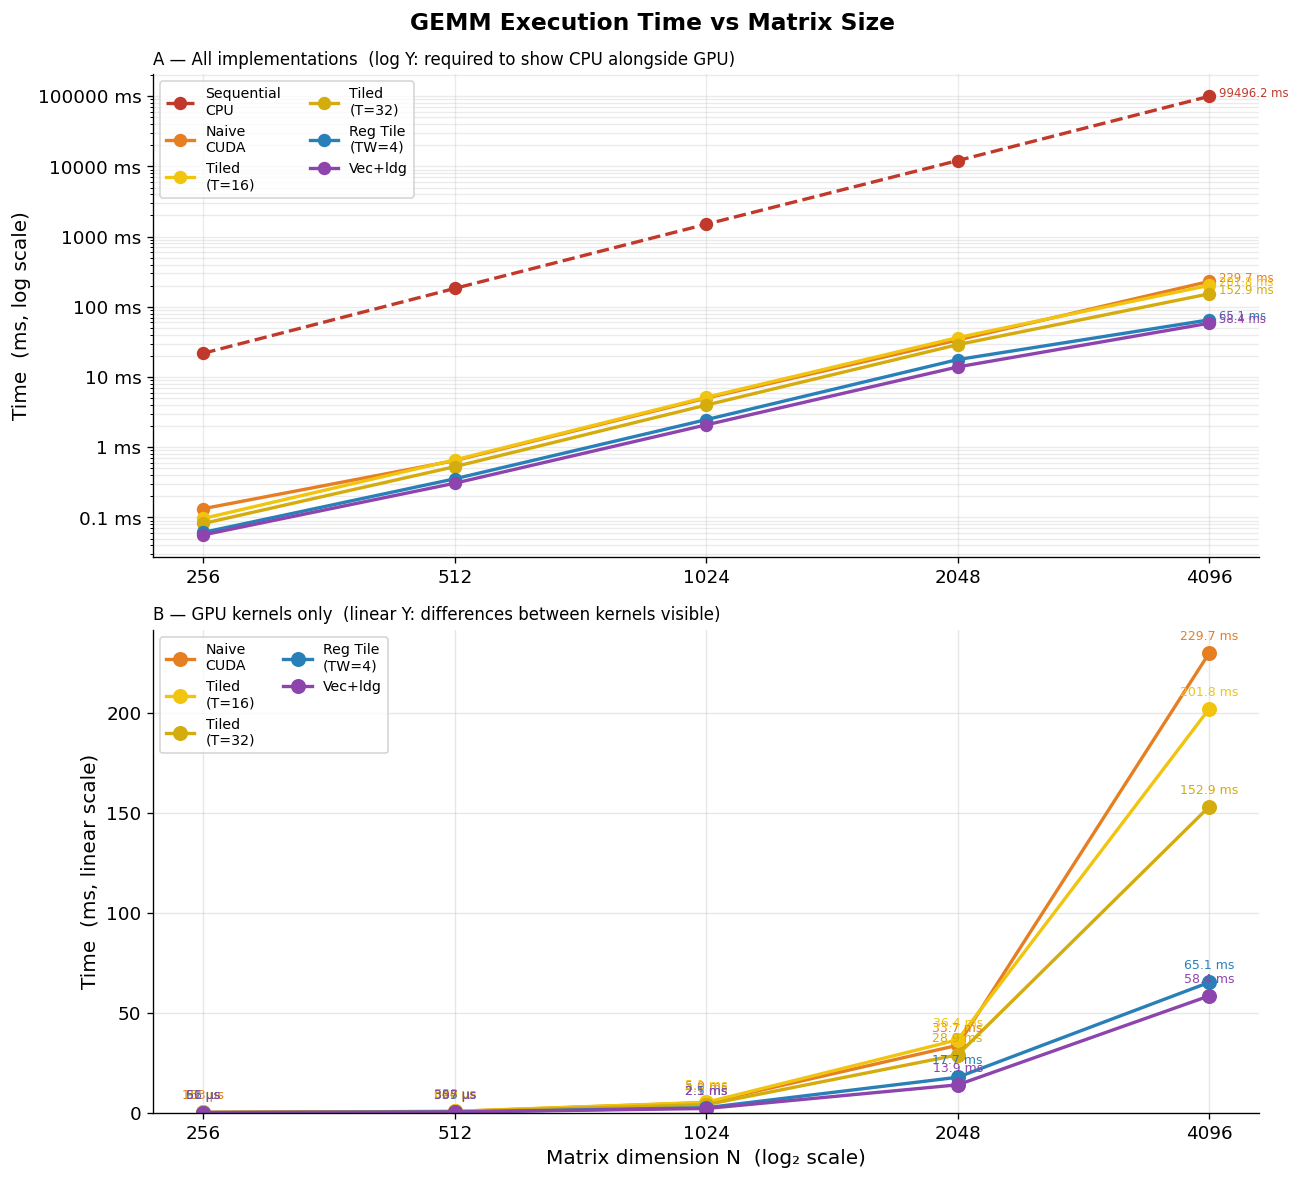

[Plot] Saved → figures/speedup_N1024.png


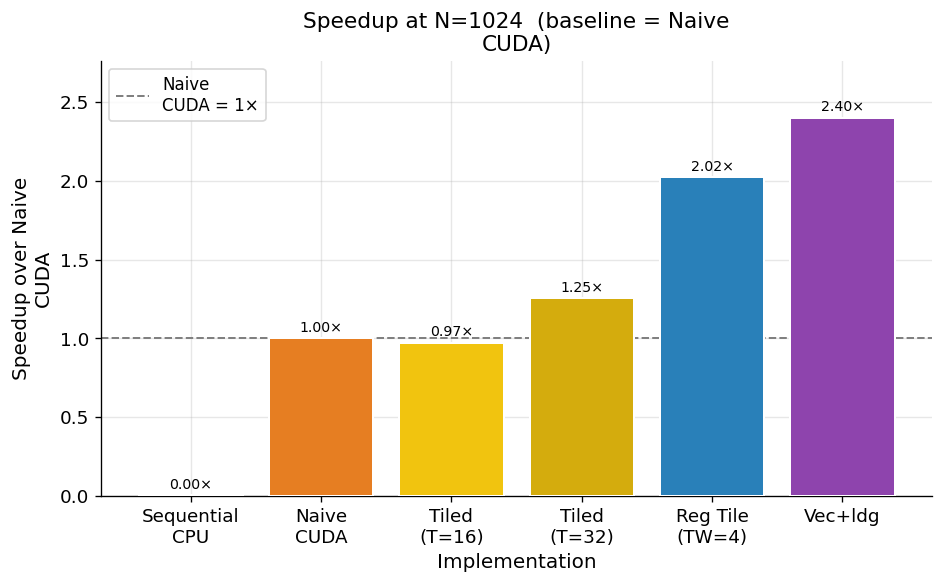

[Plot] Saved → figures/summary_table.png


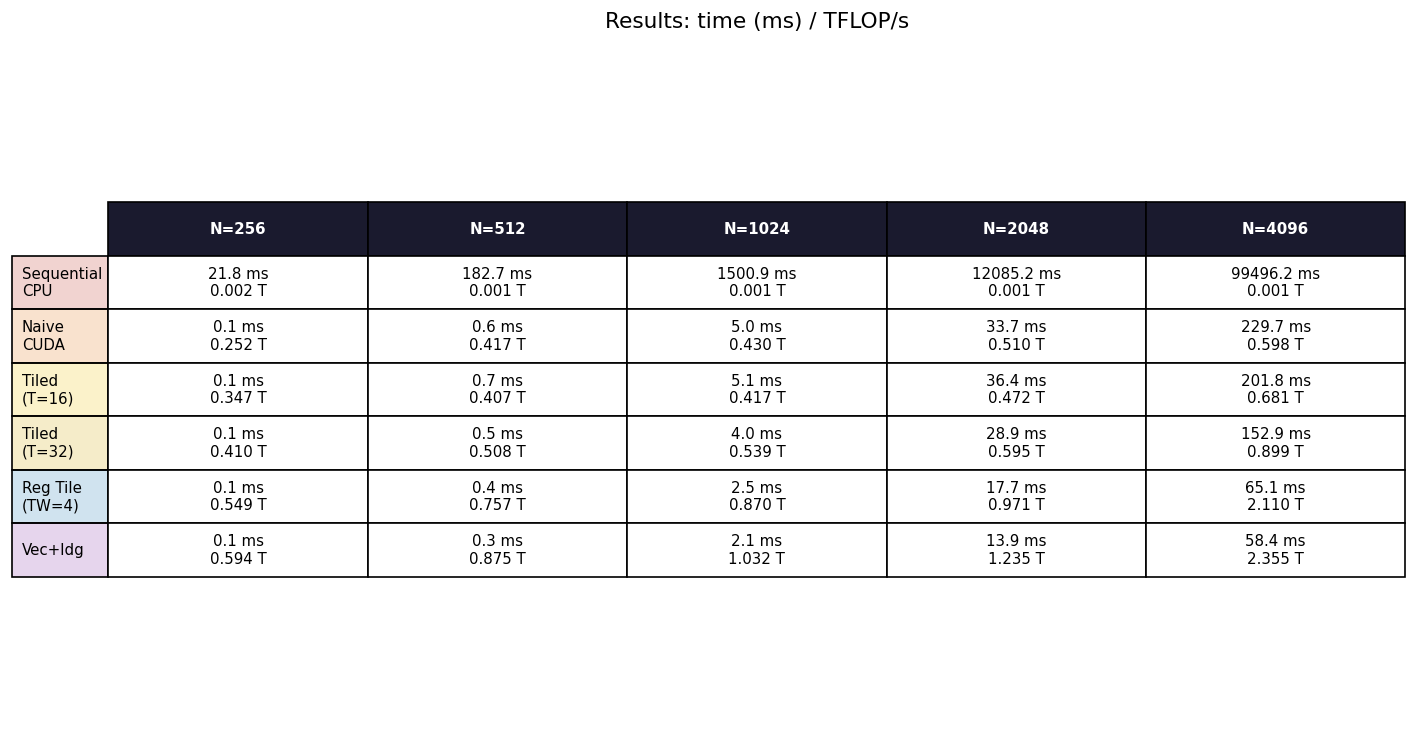

[Plot] Saved → figures/arithmetic_intensity_N1024.png


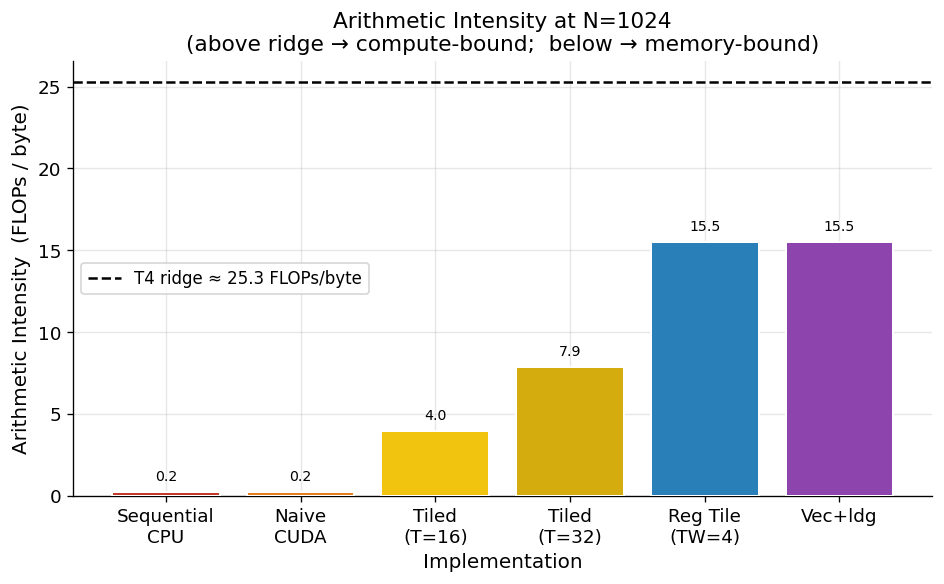

[Plot] Saved → figures/efficiency_N1024.png


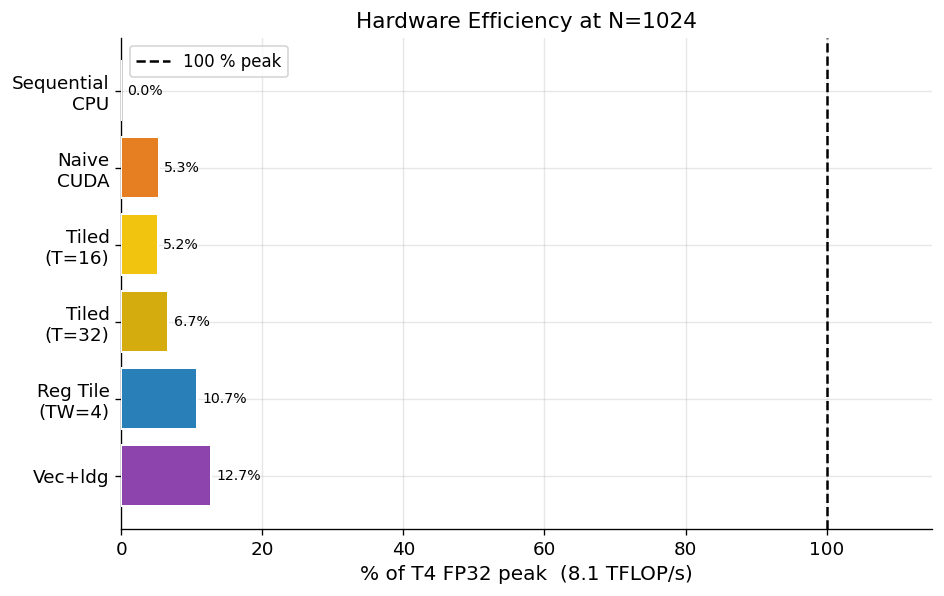

[Plot] Saved → figures/roofline_N1024.png


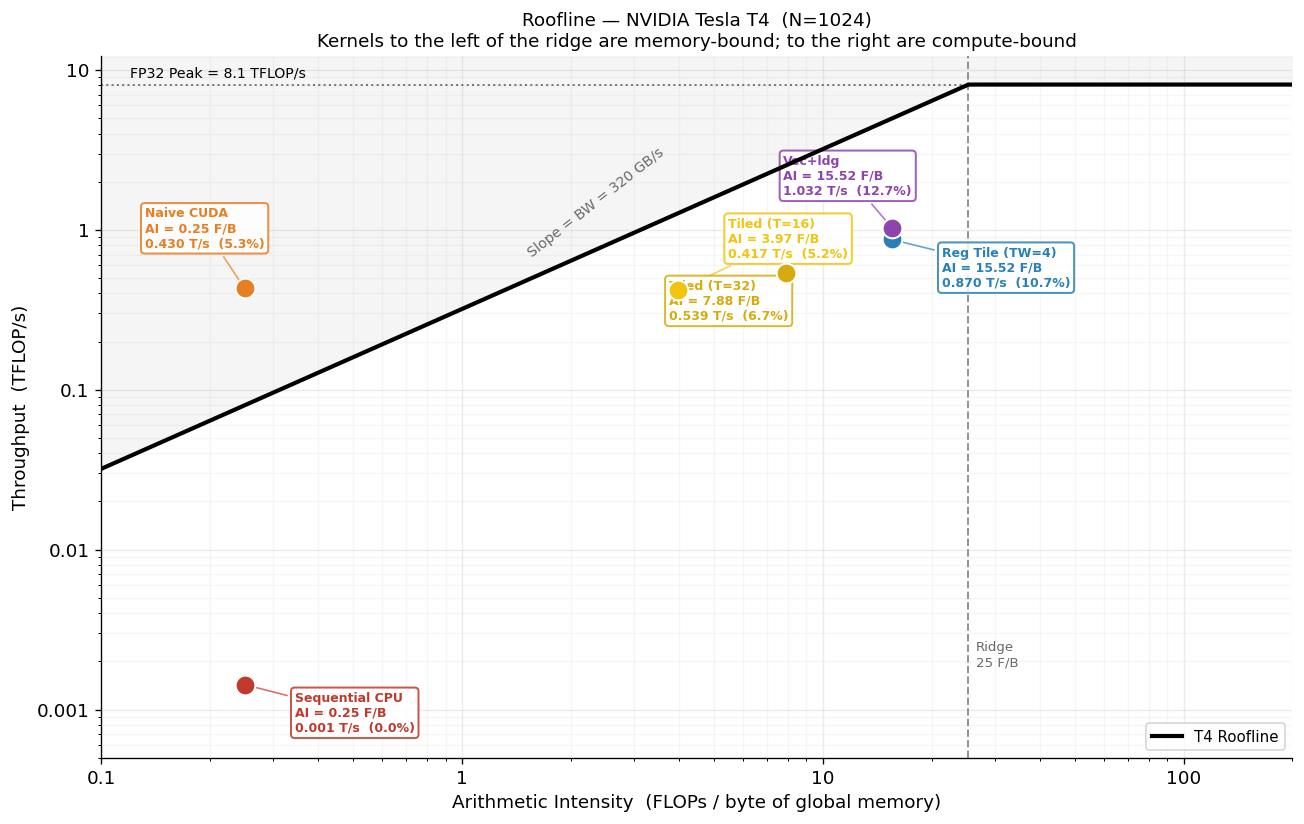

[Plot] Done.


In [49]:
plotter = GEMMPlotter(suite.best(), output_dir="./figures/")
plotter.plot_all()

[Plot] Saved → figures/bar_tflops_N512.png


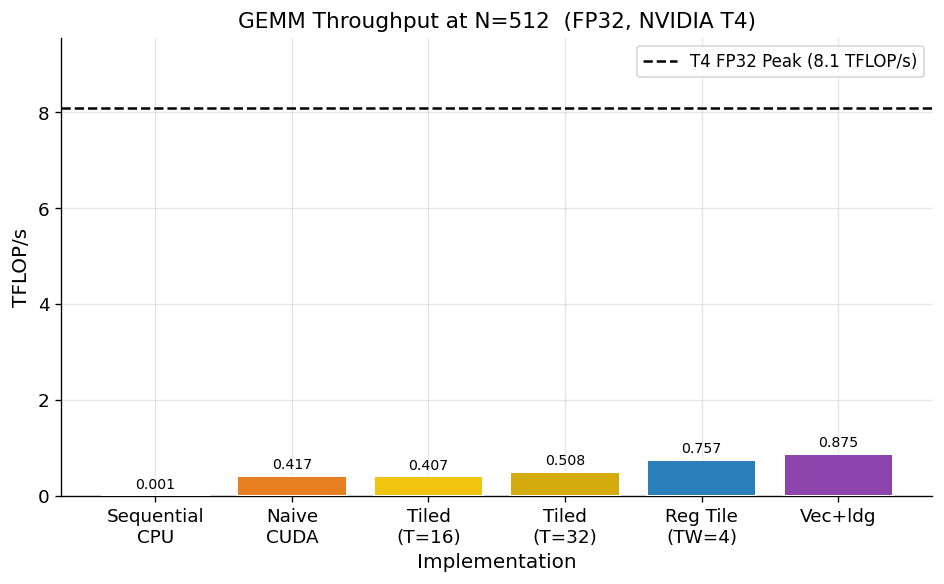

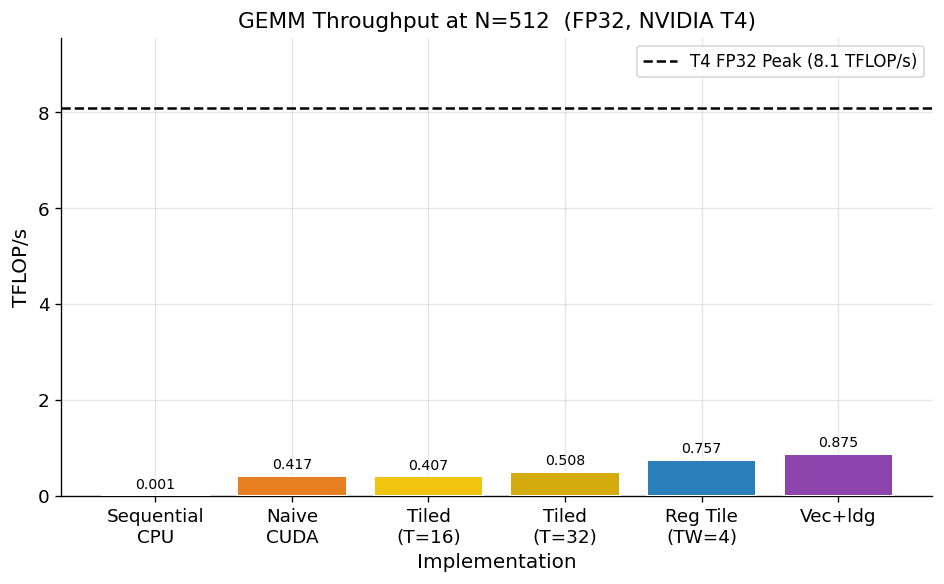

In [50]:
plotter.bar_tflops_at_N(N=512)

[Plot] Saved → figures/bar_tflops_N2048.png


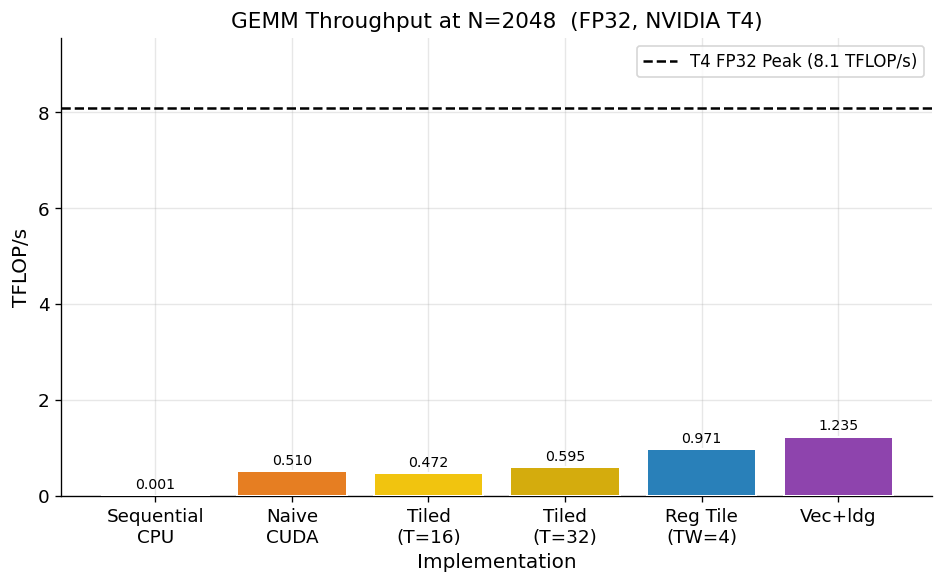

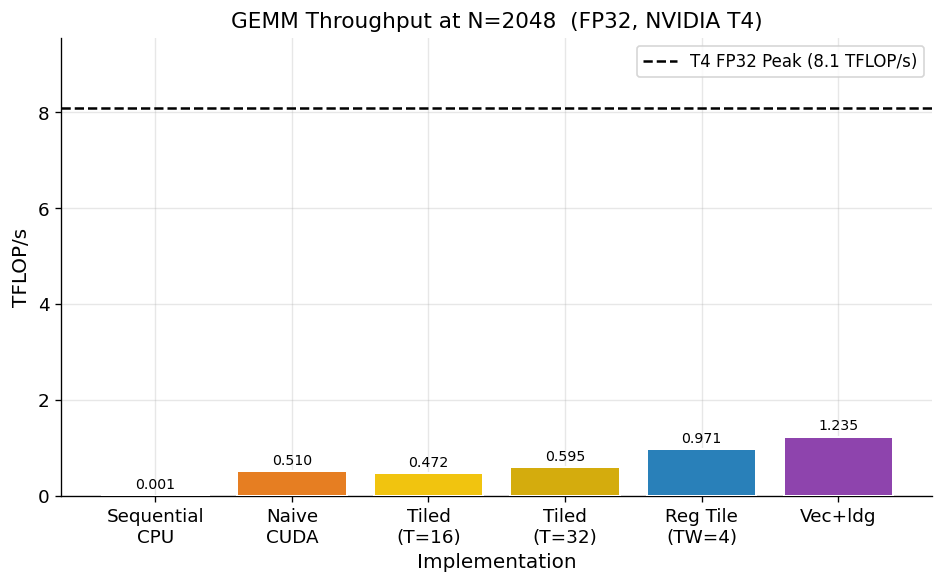

In [51]:
plotter.bar_tflops_at_N(N=2048)

[Plot] Saved → figures/bar_tflops_N4096.png


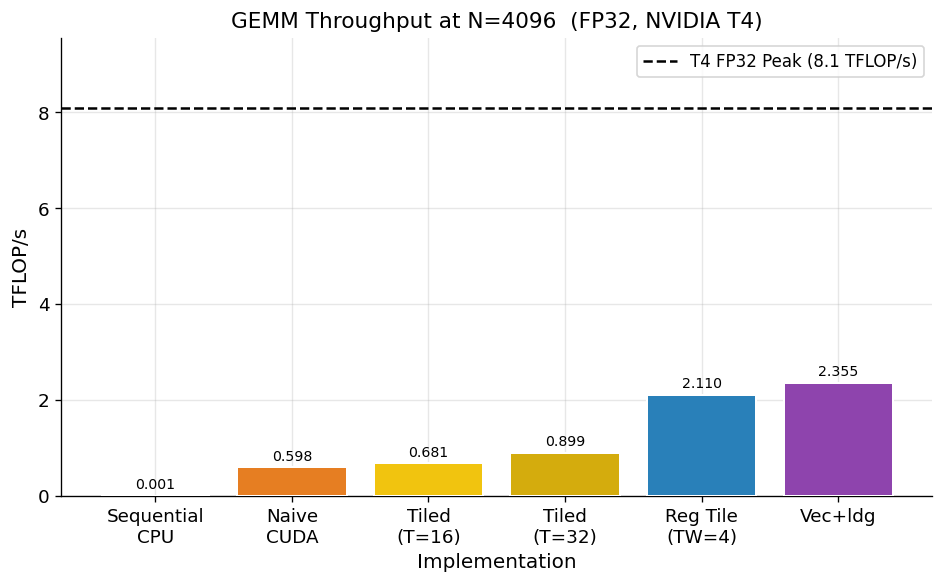

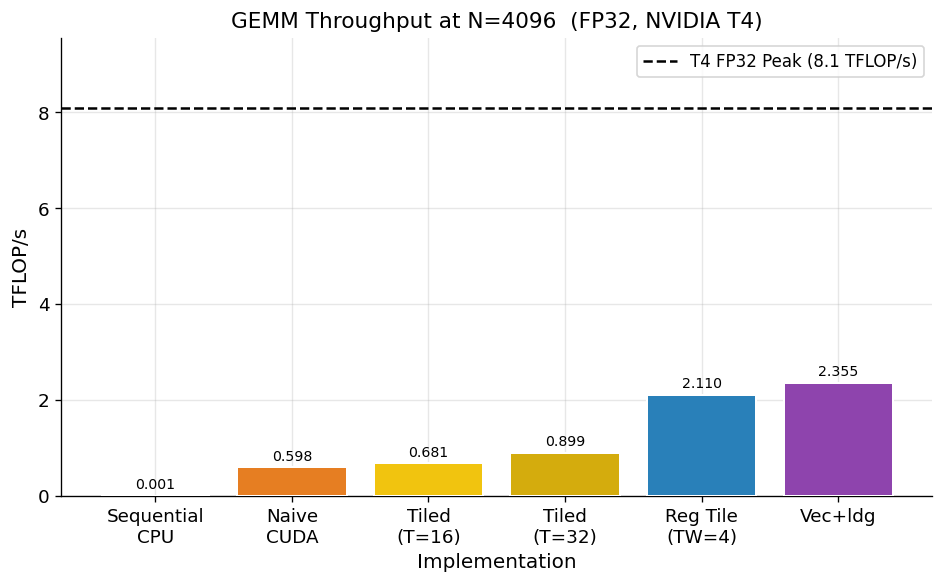

In [52]:
plotter.bar_tflops_at_N(N=4096)